<center> <img src = https://avatars.mds.yandex.net/i?id=a298685a2a26e0232f2090a93ac00fb7200b8137-5651184-images-thumbs&n=13 alt="drawing" style="width:400px;">

# <center> Предсказание честности отеля — от *Booking*

**Booking.com** — одна из ведущих мировых онлайн-платформ для бронирования отелей, апартаментов и других видов размещения. Основанная в 1996 году в Нидерландах, компания входит в состав Booking Holdings Inc., которая также владеет такими сервисами, как Kayak, Priceline и Agoda.

**Одна из проблем компании** — это нечестные отели, которые накручивают себе рейтинг. Одним из способов обнаружения таких отелей является построение модели, которая предсказывает рейтинг отеля.

Если предсказания модели сильно отличаются от фактического результата, то, возможно, отель ведёт себя нечестно, и его стоит проверить.

**Задача**:

        Необходимо создать модель машинного обучения, которая будет предсказывать *reviewer_score* - оценку, которую рецензент поставил отелю                            

Датасет содержит следующую структуру:


-   *hotel_address* — Адрес отеля.

-   *review_date* — Дата, когда рецензент разместил соответствующий отзыв (формат даты: YYYY-MM-DD).

-   *average_score* — Средний балл отеля, рассчитанный на основе последнего комментария за последний год (числовое значение).

-   *hotel_name* — Название отеля.

-   *reviewer_nationality* — Страна рецензента (название страны).

-   *negative_review* — Отрицательный отзыв, который рецензент дал отелю (текст).

-   *review_total_negative_word_counts* — Общее количество слов в отрицательном отзыве (целое число).

-   *positive_review* — Положительный отзыв, который рецензент дал отелю (текст).

-   *review_total_positive_word_counts* — Общее количество слов в положительном отзыве (целое число).

-   *reviewer_score* — Оценка, которую рецензент поставил отелю на основе своего опыта (числовое значение, обычно от 0 до 10).

-   *total_number_of_reviews_reviewer_has_given* — Количество отзывов, которые рецензент дал в прошлом (целое число).

-   *total_number_of_reviews* — Общее количество действительных отзывов об отеле (целое число).

-   *tags* — Теги, которые рецензент дал отелю (список тегов, разделённых определённым символом, например, запятой).

-   *days_since_review* — Количество дней между датой проверки и датой выгрузки данных (целое число).

-   *additional_number_of_scoring* — Количество действительных оценок без отзыва (целое число).

-   *lat* — Географическая широта отеля (числовое значение).

-   *lng* — Географическая долгота отеля (числовое значение).

В исследовании будут использованы данные с источника ["[SF-DST] Booking reviews (kaggle.com)"](https://www.kaggle.com/competitions/sf-booking)

> ## <center> **ЭТАПЫ ИССЛЕДОВАНИЯ**

1. **Исследование данных и проектирование признаков (Feature Engineering)**
    -   1.1 ЗАГРУЗКА ДАННЫХ
    -   1.2 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
    -   1.3 ВРЕМЕННЫЕ ПРИЗНАКИ
    -   1.4 ТЕКСТОВЫЕ ПРИЗНАКИ
    -   1.5 КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ
    -   1.6 ЧИСЛОВЫЕ ПРИЗНАКИ
    -   1.7 ГЕОГРАФИЧЕСКИЕ ПРИЗНАКИ
2. **Анализ и отбор признаков (Feature Selection)**
    -   2.1 АНАЛИЗ МУЛЬТКОЛЛИНЕАРНОСТИ
    -   2.2 ОТБОР ВЛИЯТЕЛЬНЫХ ПРИЗНАКОВ
3. **Обучение модели и подбор параметров (Model Training)**
4. **Интерпретация результатов**


--- 
## **Функции для EDA (*Exploratory Data Analysis*)**

In [1]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {}".format(alpha))

# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

Уровень значимости alpha = 0.05


---
## 1. **Исследование данных и проектирование признаков (Feature Engineering)** 

### **1.1 ЗАГРУЗКА ДАННЫХ**

In [2]:
#!pip install geopy
#!pip install nltk

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\97030\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\97030\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


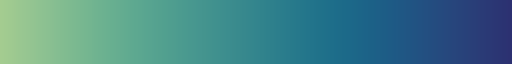

In [152]:
# импортируем библиотеки для анализа тональности текста
import nltk
# import nltk.corpus
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm 
# from nltk.stem import LancasterStemmer
# from nltk.stem import PorterStemmer
# from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize 

# загрузка словаря пунктуации для тональности текста
nltk.download('punkt')

# Загрузка словаря анализа тональности текста Natural Language Toolkit (NLTK)
nltk.downloader.download('vader_lexicon')

from sklearn import preprocessing

# импортируем географическую библиотеку
# from geopy.geocoders import ArcGIS
from geopy.distance import geodesic

# импортирование библиотек 
import pandas as pd
import numpy as np
import re 

# импортируем библиотеки для визуализации 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# импортируем библиотеки связанные с моделью
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
from sklearn.model_selection import train_test_split  # Загружаем специальный инструмент для разбивки датасета: 

# импортируем библиотеки для статистики 
from scipy import stats
import statsmodels.api as sm

# Библиотеки для отбора признаков.
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2 # хи-квадрат
from sklearn.feature_selection import f_regression 

import requests             # для отправки HTTP-запросов к API

# подбор гипперпараметров модели
import optuna

# Отключение отображения предупреждений
import warnings
warnings.filterwarnings("ignore")

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.color_palette("crest", as_cmap=True)    # Зелёная палитра (обратная для градиента



In [4]:
data = pd.read_csv('./data/hotels.csv')
hotels = data.copy()
hotels.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


### **1.2 ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ**

In [5]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

**Можно сделать выводы:**
- размерность таблицы 386803 строк и 17 столбцов 
- имеются пропуски в столбцах lat и lng 

In [6]:
# Количество числовых и текстовых столбцов датасета 
num_cols = hotels.select_dtypes(include=['number']).columns
str_cols = hotels.select_dtypes(include=['object']).columns
print("Количество числовых столбцов: {}".format(len(num_cols)))
print("Количество текстовых столбцов: {}".format(len(str_cols)))

Количество числовых столбцов: 9
Количество текстовых столбцов: 8


**Рассмотрим пропуски в данных**

In [7]:
hotels_nulls = hotels.isnull().sum()
mask = hotels_nulls > 0
display(hotels_nulls[mask].sort_values(ascending=False))

lat    2448
lng    2448
dtype: int64

Найдено 2448 пропусков в столбцах lag и lng. Далее постараемся понять, почему эти признаки имеют пропуски.

In [8]:
# выведем адреса, у которых имеются пропуски в lat и lng 
mask_null = hotels.lat.isnull()
hotels[mask_null]['hotel_address'].unique()

array(['Savoyenstra e 2 16 Ottakring 1160 Vienna Austria',
       '23 Rue Damr mont 18th arr 75018 Paris France',
       'Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria',
       'W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria',
       '4 rue de la P pini re 8th arr 75008 Paris France',
       'Sieveringer Stra e 4 19 D bling 1190 Vienna Austria',
       'Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria',
       'Bail n 4 6 Eixample 08010 Barcelona Spain',
       'Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria',
       'Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria',
       'Paragonstra e 1 11 Simmering 1110 Vienna Austria',
       'W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria',
       '20 Rue De La Ga t 14th arr 75014 Paris France',
       'Hasenauerstra e 12 19 D bling 1190 Vienna Austria',
       'Sep lveda 180 Eixample 08011 Barcelona Spain',
       'Pau Clar s 122 Eixample 08009 Barcelona Spain',
       'Josefst dter Stra e 22 08 Jos

В адресах, в которых пропущены значения долготы и широты, допущены ошибки. Это могло случится при сборе данных, некоторые адреса имеют символы, которых нет в английском алфавите. Далее заполним пропуски в данных ->

In [9]:
# Вручную собираем данные о долготе и широте пропущенных данных и записываем в список.
coordinates = [
    ('W hringer Stra e 33 35 09 Alsergrund 1090 Vienna Austria', 48.220301, 16.357513),  
    ('Gr nentorgasse 30 09 Alsergrund 1090 Vienna Austria', 48.225182, 16.358573),  
    ('23 Rue Damr mont 18th arr 75018 Paris France', 48.8926, 2.3274),  
    ('Josefst dter Stra e 10 12 08 Josefstadt 1080 Vienna Austria', 48.210918, 16.347119),  
    ('Taborstra e 8 A 02 Leopoldstadt 1020 Vienna Austria', 48.218213, 16.394110),  
    ('Josefst dter Stra e 22 08 Josefstadt 1080 Vienna Austria', 48.2115, 16.3462), 
    ('Bail n 4 6 Eixample 08010 Barcelona Spain', 41.391194, 2.155134),  
    ('Landstra er G rtel 5 03 Landstra e 1030 Vienna Austria', 48.1996, 16.3388),  
    ('4 rue de la P pini re 8th arr 75008 Paris France', 48.8749, 2.3001), 
    ('20 Rue De La Ga t 14th arr 75014 Paris France', 48.8331, 2.3269), 
    ('W hringer Stra e 12 09 Alsergrund 1090 Vienna Austria', 48.220720, 16.352360),  
    ('Savoyenstra e 2 16 Ottakring 1160 Vienna Austria', 48.211969, 16.311241),  
    ('Pau Clar s 122 Eixample 08009 Barcelona Spain', 41.504994, 2.245959),  
    ('Sieveringer Stra e 4 19 D bling 1190 Vienna Austria', 48.245935, 16.341397),  
    ('Paragonstra e 1 11 Simmering 1110 Vienna Austria', 48.176599, 16.413999), 
    ('Hasenauerstra e 12 19 D bling 1190 Vienna Austria', 48.233495, 16.345556),  
    ('Sep lveda 180 Eixample 08011 Barcelona Spain', 41.3793, 2.1590)  
]

# Заполняем датафрейм значениями из списка
for addr, lat, lng in coordinates:
    hotels.loc[hotels['hotel_address'] == addr, 'lat'] = lat
    hotels.loc[hotels['hotel_address'] == addr, 'lng'] = lng

**Рассмотрим дубликаты в данных:**

In [10]:
# поиск дубликатов
hotels_dupls = hotels.duplicated()
print(f"Найдено дубликатов в данных: {hotels_dupls.value_counts().iloc[1]}")

# удаляем дубликаты
print("Количество строк до очистки дубликатов: {}".format(hotels.shape[0]))
hotels = hotels.drop_duplicates()
print("Количество строк после очистки дубликатов: {}".format(hotels.shape[0]))

Найдено дубликатов в данных: 307
Количество строк до очистки дубликатов: 386803
Количество строк после очистки дубликатов: 386496


**Рассмотрим количество уникальных значений каждого столбца:**

In [11]:
for column in hotels.columns:
    num_unique = hotels[column].nunique()
    print("Количество уникальных значений {}: {}".format(column, num_unique))

Количество уникальных значений hotel_address: 1493
Количество уникальных значений additional_number_of_scoring: 480
Количество уникальных значений review_date: 731
Количество уникальных значений average_score: 34
Количество уникальных значений hotel_name: 1492
Количество уникальных значений reviewer_nationality: 225
Количество уникальных значений negative_review: 248828
Количество уникальных значений review_total_negative_word_counts: 402
Количество уникальных значений total_number_of_reviews: 1142
Количество уникальных значений positive_review: 311737
Количество уникальных значений review_total_positive_word_counts: 354
Количество уникальных значений total_number_of_reviews_reviewer_has_given: 194
Количество уникальных значений reviewer_score: 37
Количество уникальных значений tags: 47135
Количество уникальных значений days_since_review: 731
Количество уникальных значений lat: 1489
Количество уникальных значений lng: 1489


---
## <CENTER> ***ПОДЫТОЖИМ!***
- размерность таблицы 386803 строк и 17 столбцов 
- имеются пропуски в столбцах *lat* и *lng*
- нашли реальные кординаты и заполнили пропуски  
- удалены 307 дубликатов 
- 9 числовых столбцов и 8 текстовых
- на первый взгляд кроме столбца *tags* категориальных призаков не обнаружено 

---
### **1.3 ВРЕМЕННЫЕ ПРИЗНАКИ**

К временным признакам отнесем такие как: 
-   *review_date* — Дата, когда рецензент разместил соответствующий отзыв (формат даты: YYYY-MM-DD).
-   *days_since_review* — Количество дней между датой проверки и датой выгрузки данных (целое число).

**Рассмотрим признак *review_date*:**

Тип данных: datetime64[ns]


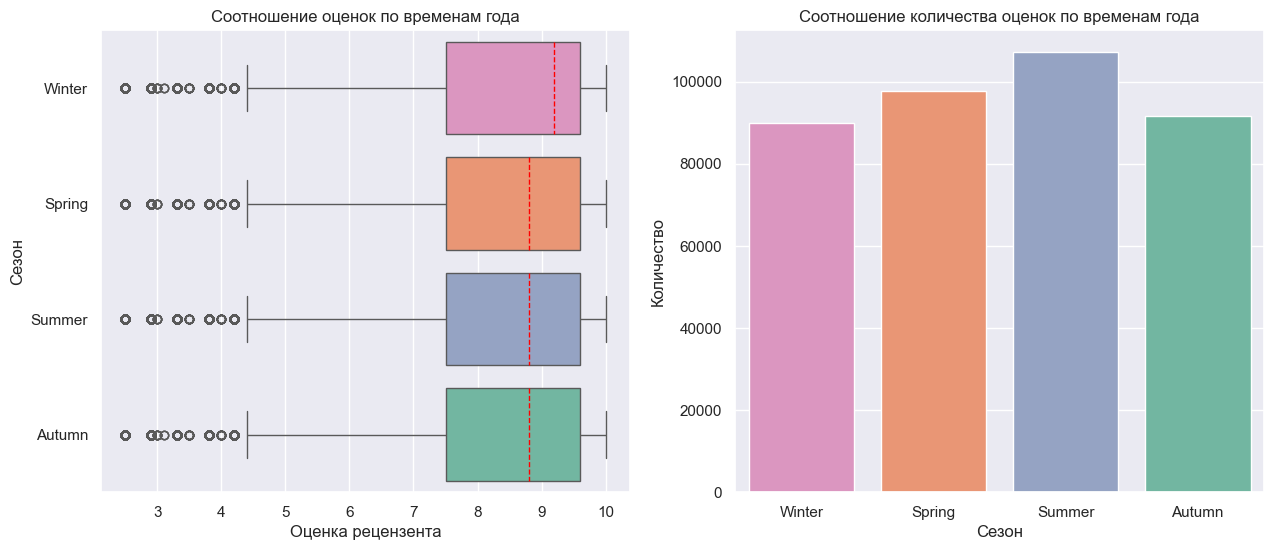

In [12]:
palette = sns.color_palette("Set2")

# преобразуем в тип данных datetime
hotels['review_date'] = pd.to_datetime(hotels['review_date'])
print("Тип данных: {}".format(hotels.review_date.dtype))

# Создаем временные признаки (год, месяц, сезон)
hotels['review_year'] = hotels['review_date'].dt.year.astype('category')
hotels['review_month'] = hotels['review_date'].dt.month.astype('category')

# Создаем категориальный признак время года 
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
    
hotels['review_season'] = hotels['review_date'].dt.month.apply(get_season)
# присвоим тип данных category
hotels['review_season'] = hotels['review_season'].astype('category')

# коробчатая диаграмма оценки рецензента по сезонам
fig, axes = plt.subplots(1, 2, figsize=(15,6))
sns.boxplot(hotels,
            x='reviewer_score',
            y='review_season',
            orient='h', 
            hue='review_season',
            medianprops={"color": "red", "linestyle": '--'},
            order=['Winter', 'Spring', 'Summer', 'Autumn'],
            ax=axes[0],
            palette=palette)
axes[0].set(xlabel="Оценка рецензента", ylabel="Сезон")
axes[0].set_title("Соотношение оценок по временам года")

# соотношение количества оценок по временам года
sns.countplot(hotels,
              x=hotels['review_season'],
              ax=axes[1],
              order=['Winter', 'Spring', 'Summer', 'Autumn'],
              hue='review_season',
              palette=palette)
axes[1].set(xlabel="Сезон", ylabel="Количество")
axes[1].set_title("Соотношение количества оценок по временам года")

plt.show()

# удаляем дату отзыва
hotels.drop('review_date', axis=1, inplace=True)

In [13]:
hotels.groupby(['review_season'])['reviewer_score'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
review_season,,,,,,,,
Autumn,91649.0,8.30,1.67,2.5,7.5,8.8,9.6,10.0
Spring,97747.0,8.43,1.61,2.5,7.5,8.8,9.6,10.0
Summer,107192.0,8.38,1.65,2.5,7.5,8.8,9.6,10.0
Winter,89908.0,8.48,1.60,2.5,7.5,9.2,9.6,10.0


**ВЫВОДЫ:**
-   ничего удивительного больше всего оценок летом
-   с лета на весну резкий спад количества отзывов
-   есть курортные отели в данных

**Рассмотрим признак *days_since_review*:**

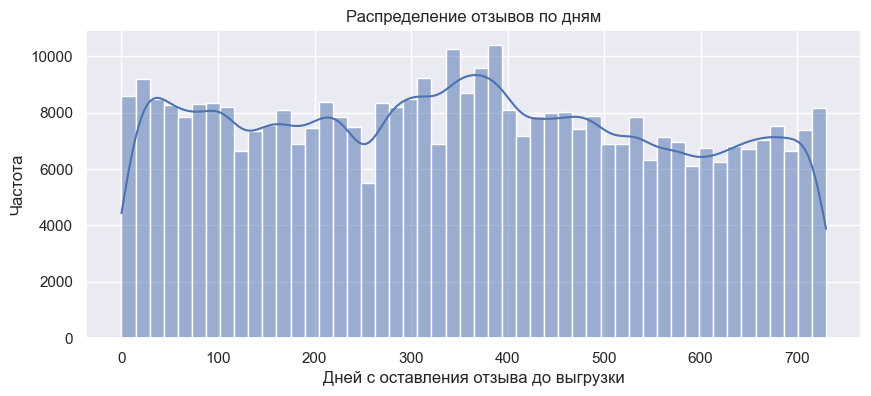

In [14]:
# Преобразуем в числовой формат 
hotels['days_since_review_num'] = hotels['days_since_review'].str.extract('(\d+)').astype(np.int16)

# Распределение по дням
plt.figure(figsize=(10, 4))
sns.histplot(data=hotels,
             x='days_since_review_num',
             bins=50,
             kde=True)
plt.ylabel("Частота")
plt.xlabel("Дней с оставления отзыва до выгрузки")
plt.title('Распределение отзывов по дням')
plt.show()

In [15]:
display(hotels.days_since_review.describe())

# удаляем days_scince_review
hotels.drop('days_since_review', axis=1, inplace=True)

count     386496
unique       731
top       1 days
freq        1910
Name: days_since_review, dtype: object

-   Всего 386 496 записей (отзывов) в датасете.
-   Уникальных значений 731 — это означает, что отзывы охватывают примерно 2 года (731 день ≈ 2 года).
-   Наиболее частый вариант — "1 days" (встречается 1910 раз). Это говорит о том, что в датасете много совсем свежих отзывов.


---
## <CENTER> ***ПОДЫТОЖИМ!***

-   созданы два новых признака *review_year* и *review_month*
-   больше всего отзывов летом 
-   в датасете много свежих отзывов 

---
### **1.4 ТЕКСТОВЫЕ ПРИЗНАКИ** 

**Текстовые признаки:**
-   *hotel_address* — Адрес отеля.

-   *review_date* — Дата, когда рецензент разместил соответствующий отзыв (формат даты: YYYY-MM-DD)

-   *hotel_name* — Название отеля.

-   *reviewer_nationality* — Страна рецензента (название страны).

-   *negative_review* — Отрицательный отзыв, который рецензент дал отелю (текст).

-   *positive_review* — Положительный отзыв, который рецензент дал отелю (текст).

-   *tags* — Теги, которые рецензент дал отелю (список тегов, разделённых определённым символом, например, запятой).

-   *days_since_review* — Количество дней между датой проверки и датой выгрузки данных (целое число).


Из них *review_date* и *days_since_review* - временные признаки, *tags* - категориальный

**Потенциально новые признаки:**
-   страна отеля;
-   город отеля;
-   индекс;

Страна и город - сильные признаки, могли бы сильно поменять ход исследования. Индекс, тоже не мало важный признак, но в данном исследовании он будет опущен, так как информации о географическом местоположении - достаточно (на мой взгляд).

In [16]:
# Рассмотрим структуру адрессов (в которых нет пропусокв в данных), после
# найдем отличительные черты и попробуем как-нибудь классифицировать или разбить на группы
for i in range(0, 25):
    print(hotels.hotel_address.iloc[i])

Stratton Street Mayfair Westminster Borough London W1J 8LT United Kingdom
130 134 Southampton Row Camden London WC1B 5AF United Kingdom
151 bis Rue de Rennes 6th arr 75006 Paris France
216 Avenue Jean Jaures 19th arr 75019 Paris France
Molenwerf 1 1014 AG Amsterdam Netherlands
Via Mecenate 121 20138 Milan Italy
97 Cromwell Road Kensington and Chelsea London SW7 4DN United Kingdom
Josefsgasse 4 6 08 Josefstadt 1080 Vienna Austria
190 Queen s Gate Kensington and Chelsea London SW7 5EX United Kingdom
Holland Park Avenue Kensington and Chelsea London W11 4UL United Kingdom
Molenwerf 1 1014 AG Amsterdam Netherlands
34 44 Barkston Gardens Kensington and Chelsea London SW5 0EW United Kingdom
16 Sumner Place Kensington and Chelsea London SW7 3EG United Kingdom
97 Cromwell Road Kensington and Chelsea London SW7 4DN United Kingdom
Putget 68 Sarri St Gervasi 08023 Barcelona Spain
Caspe 103 Eixample 08013 Barcelona Spain
1 Kings Cross Road Islington London WC1X 9HX United Kingdom
Wrights Lane Kens

Изучив даннные можно сделать вывод, что отели находятся только в 6 странах, для каждого из случаев обработаем данные для извлечения города и страны

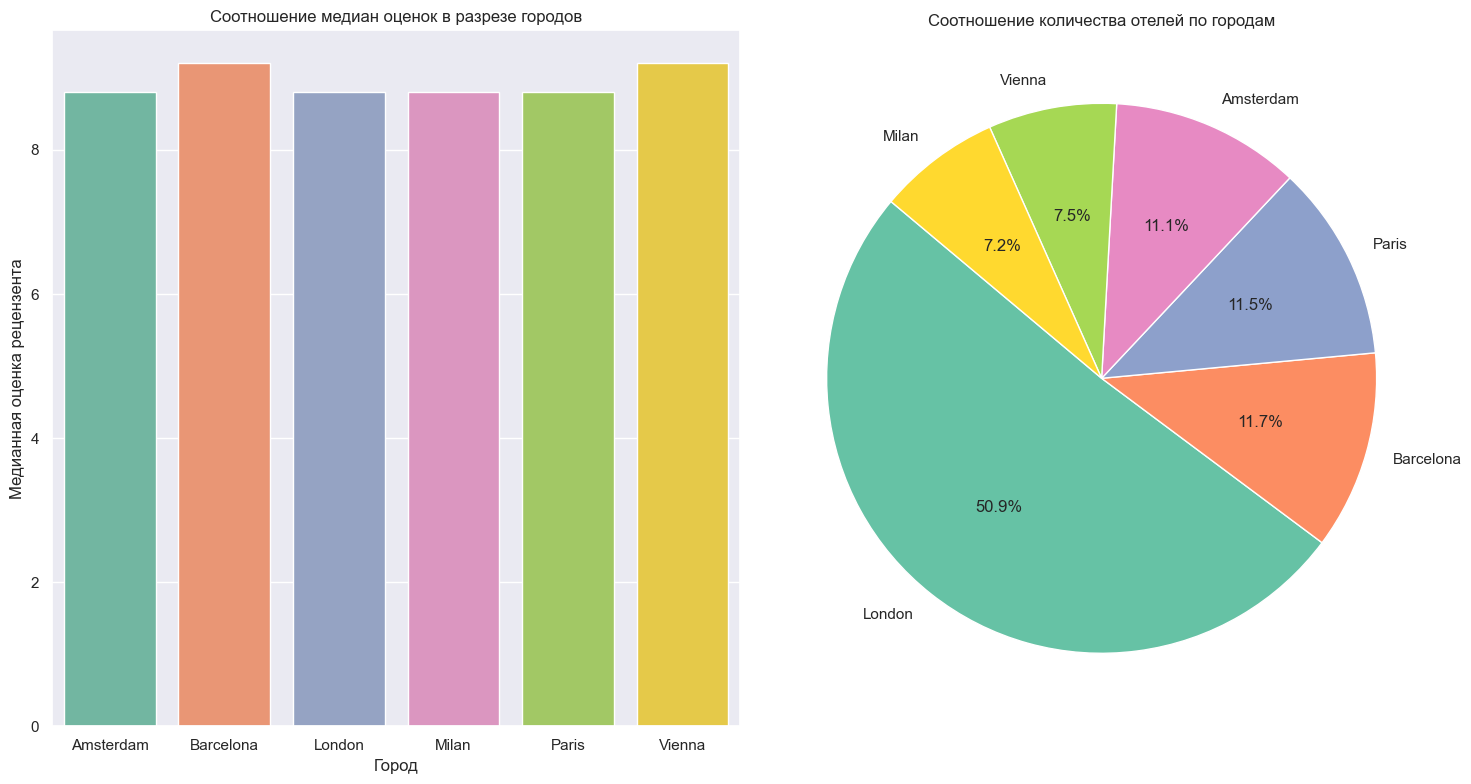

In [17]:
# Функция для извлечения города и страны
def extract_city_country(address):
    address_splited = address.split() 
    
    # Условие для United_Kindom 
    if address_splited[-1] == 'Kingdom':
        country = address_splited[-2] + ' ' + address_splited[-1]
        city = address_splited[-5]
    
    # Условие для остальных вариантов
    else:
        city, country = address_splited[-2::]
    
    return city, country
    
# Применяем к столбцу
hotels[['hotel_city', 'hotel_country']] = hotels['hotel_address'].apply(
    lambda x: pd.Series(extract_city_country(x))
)

# удаляем исходный признак
hotels.drop('hotel_address', axis=1, inplace=True)

# Преобразуем в категориальный тип данных
hotels['hotel_country'] = hotels['hotel_country'].astype('category')
hotels['hotel_city'] = hotels['hotel_city'].astype('category') 


'''-----------------------Визуализация результатов-----------------------'''

# Смотрим распределение отелей по городам
fig, axes = plt.subplots(1, 2, figsize=(15, 8))


# Группируем по названию отеля и расчитываем медианную оценку
cities_score = hotels.groupby('hotel_city')['reviewer_score'].median().reset_index()

# Строим столбчатую диаграмму
sns.barplot(
    x=cities_score.hotel_city, 
    y=cities_score['reviewer_score'],
    ax=axes[0],
    palette=palette)

axes[0].set_title("Соотношение медиан оценок в разрезе городов")
axes[0].set(xlabel="Город", ylabel='Медианная оценка рецензента')


# Смотрим распределение отелей по городам
city_counts = hotels.hotel_city.value_counts()

# Строим круговую диаграмму
axes[1].pie(
    city_counts,
    labels = city_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
)
axes[1].set_title("Соотношение количества отелей по городам")
plt.tight_layout()

In [18]:
hotels.groupby(['hotel_city'])['reviewer_score'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
hotel_city,,,,,,,,
Amsterdam,43004.0,8.45,1.60,2.5,7.5,8.8,9.6,10.0
Barcelona,45132.0,8.55,1.56,2.5,7.9,9.2,9.6,10.0
London,196773.0,8.33,1.67,2.5,7.5,8.8,9.6,10.0
Milan,27882.0,8.36,1.64,2.5,7.5,8.8,9.6,10.0
Paris,44528.0,8.42,1.65,2.5,7.5,8.8,9.6,10.0
Vienna,29177.0,8.55,1.51,2.5,7.9,9.2,9.6,10.0


**Выводы:**
-   В датасете представленны отели 6 стран и по каждой стране по 1 городу 
-   Лондон лидирует по количеству рецензентов (196,774)
-   Барселона и Амстердам имеют сопоставимое количество рецензентов (~45,000)
-   Вена и Милан представлены наименьшим количеством рецензентов (~29,000 и ~27,000 соответственно)
-   Наивысшие средние оценки у Барселоны и Вены (8.55)
-   Лондон имеет самую низкую среднюю оценку (8.33) среди всех городов
-   Во всех городах минимальная оценка 2.5, максимальная - 10.0



 **Создадим признак *is_patriot* - рецензент посещал отель в своей стране или нет**

In [19]:
# 1. Очистим пробелы в 'reviewer_nationality' 
hotels['reviewer_nationality'] = hotels['reviewer_nationality'].str.strip()

hotels['is_patriot'] = hotels['hotel_country'] == hotels['reviewer_nationality']

# 3. Проверим результат
print("Процентное соотношение *патриотов*: {:.1f}%".format(
    (hotels['is_patriot'].sum() / hotels.shape[0])*100))

hotels['is_patriot'] = hotels['is_patriot'].astype('category')
display(hotels[hotels['is_patriot']].head(3))


Процентное соотношение *патриотов*: 34.7%


,additional_number_of_scoring,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,...,tags,lat,lng,review_year,review_month,review_season,days_since_review_num,hotel_city,hotel_country,is_patriot
0,581,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,...,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",51.507894,-0.143671,2016,2,Winter,531,London,United Kingdom,True
1,299,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,...,"[' Business trip ', ' Couple ', ' Standard Dou...",51.521009,-0.123097,2017,1,Winter,203,London,United Kingdom,True
6,854,7.8,Holiday Inn London Kensington Forum,United Kingdom,Nothing it was lovely,6,3867,Very central location 2 minutes walk from Glo...,29,4,...,"[' Leisure trip ', ' Couple ', ' Double Room N...",51.494231,-0.185114,2017,5,Spring,77,London,United Kingdom,True


> #### **Создадим новые признаки на основе страны рецензента:**

**Уровень экономического развития страны рецензента и признаки Хофстеде**

Немало важным фактором является происхождение рецензента, по его стране можно создать признаки экономического развития страны, а также признаки Хофстеде.

✅ Гость оценивает отель исходя из своих культурных норм и ожиданий.

✅ Объясняют разницу в восприятии - почему один и тот же отель американец оценивает на 9, а немец на 7.


In [20]:
# Загрузка актуальной классификации стран по уровню дохода от Всемирного банка
def load_income_levels():
    url = "https://api.worldbank.org/v2/country?format=json&per_page=300"
    response = requests.get(url)  # отправляем GET-запрос к API
    data = response.json()        # преобразуем ответ в формат JSON
    
    countries_data = data[1]      # получаем список стран (второй элемент ответа)
    income_levels = {}           # создаем пустой словарь для результатов
    
    # Перебираем все страны в ответе
    for country in countries_data:
        # Проверяем, что у страны есть нужные поля
        if 'incomeLevel' in country and 'id' in country and 'name' in country:
            country_name = country['name']                  # название страны
            income_level = country['incomeLevel']['value']  # уровень дохода
            income_levels[country_name] = income_level     # добавляем в словарь
    
    return income_levels  # возвращаем словарь: {'USA': 'High income', ...}

# Создаем мэппинг для классификации
income_levels = load_income_levels()
print(income_levels)

{'Aruba': 'High income', 'Africa Eastern and Southern': 'Aggregates', 'Afghanistan': 'Low income', 'Africa': 'Aggregates', 'Africa Western and Central': 'Aggregates', 'Angola': 'Lower middle income', 'Albania': 'Upper middle income', 'Andorra': 'High income', 'Arab World': 'Aggregates', 'United Arab Emirates': 'High income', 'Argentina': 'Upper middle income', 'Armenia': 'Upper middle income', 'American Samoa': 'High income', 'Antigua and Barbuda': 'High income', 'Australia': 'High income', 'Austria': 'High income', 'Azerbaijan': 'Upper middle income', 'Burundi': 'Low income', 'East Asia & Pacific (IBRD-only countries)': 'Aggregates', 'Europe & Central Asia (IBRD-only countries)': 'Aggregates', 'Belgium': 'High income', 'Benin': 'Lower middle income', 'Burkina Faso': 'Low income', 'Bangladesh': 'Lower middle income', 'Bulgaria': 'High income', 'IBRD countries classified as high income': 'Aggregates', 'Bahrain': 'High income', 'Bahamas, The': 'High income', 'Bosnia and Herzegovina': 'Up

In [21]:
# Функция для определения уровня дохода
def get_income_level(country):
    country = country.strip()  # удаляем лишние пробелы в названии страны
    # Ищем страну в словаре, если не находим - возвращаем 'Unknown'
    return income_levels.get(country, 'Unknown')

In [22]:
unknown_country = hotels.reviewer_nationality.apply(get_income_level)
unknown_country.value_counts()

reviewer_nationality
High income            317053
Unknown                 44907
Upper middle income     16042
Lower middle income      8302
Low income                166
Not classified             26
Name: count, dtype: int64

Заметим, что много стран было отмеченно как unknown. Скорее всего название многих стран немного отличается в формате записи. Например: 'United States of America': 'United States' 

In [23]:
# страны по убыванию, которые были отмечены как 'unknown'
hotels.loc[unknown_country == 'Not classified','reviewer_nationality'].value_counts()

reviewer_nationality
Ethiopia    26
Name: count, dtype: int64

In [24]:
# Создаем словарь для преобразования ваших названий в стандартные
country_name_mapping = {
    'United States of America': 'United States',
    'Hong Kong': 'Hong Kong SAR, China',
    'Iran': 'Iran, Islamic Rep.',
    'South Korea': 'Korea, Rep.',
    'Vietnam': 'Viet Nam',
    'Russia': 'Russian Federation',
    'Turkey': 'Turkiye',
    'Egypt': 'Egypt, Arab Rep.',
    'Slovakia': 'Slovak Republic',
    'Czech Republic': 'Czechia',
    'Taiwan': 'China', # частично китай
    'Venezuela': 'Venezuela, RB',
    'Macedonia': 'North Macedonia',
    'Ivory Coast': 'Cote d\'Ivoire',
    'Syria': 'Syrian Arab Republic',
    'Yemen': 'Yemen, Rep.',
    'Laos': 'Lao PDR',
    'Congo': 'Congo, Rep.',
    'Democratic Republic of the Congo': 'Congo, Dem. Rep.',
    'East Timor': 'Timor-Leste',
    'Swaziland': 'Eswatini',
    'Brunei': 'Brunei Darussalam',
    # Для остальных можно оставить как есть
}

# Проверим на корректность текущего словаря
for key in country_name_mapping.keys():

    new_name = country_name_mapping[key]
    category = get_income_level(new_name)
    
    if category == 'Unknown':
        raise ValueError(f"Неправильное обозначение в словаре: {new_name}")
        

# если ошибок нет - значит словарь корректный
# Переходим к группировке

# Функция для определения уровня дохода (усовершенственная версия)
def get_income_level(country):
    country = country.strip()  # удаляем лишние пробелы в названии страны
    
    # данных по этим стране нет
    if country in ('Venezuela', 'Ethiopia'):
        return 'Unknown'
    
    # если формат названий отличается от всемирного банка 
    if country in country_name_mapping.keys():
        return income_levels.get(country_name_mapping[country], 'Unknown')

    # Ищем страну в словаре, если не находим - возвращаем 'Unknown'
    return income_levels.get(country, 'Unknown')

hotels['economy_level_RC'] = hotels.reviewer_nationality.apply(get_income_level)
display(hotels['economy_level_RC'].value_counts())

# Определяем порядок категорий от низшего к высшему
income_order = [['Unknown', 'Low income', 'Lower middle income', 'Upper middle income', 'High income']]

# Создаем и закодируем порядковый признак
ordinal_encoder = preprocessing.OrdinalEncoder(categories=income_order)
hotels['economy_level_encoded'] = ordinal_encoder.fit_transform(hotels[['economy_level_RC']])

economy_level_RC
High income            352036
Upper middle income     21863
Lower middle income     10259
Unknown                  2130
Low income                208
Name: count, dtype: int64

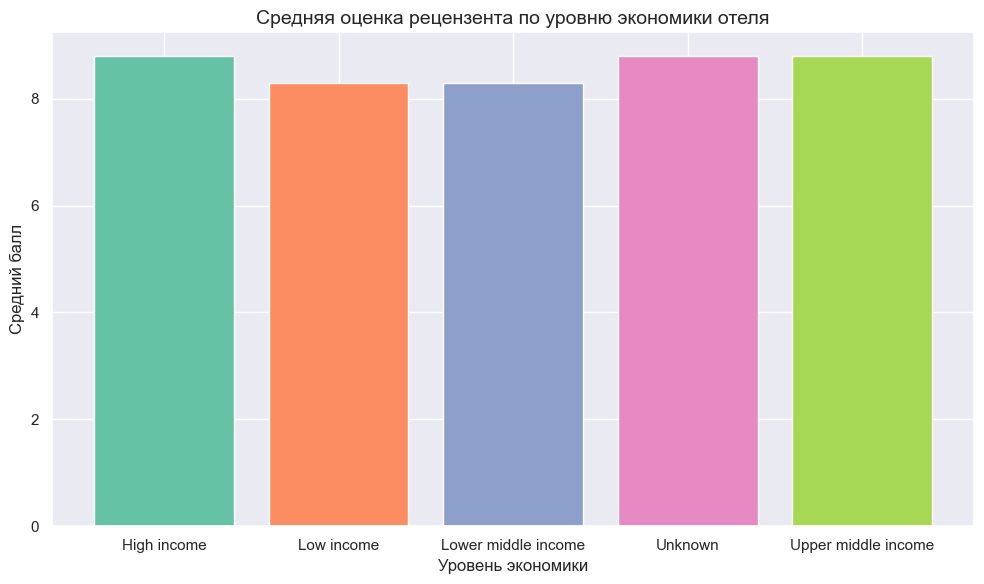

In [25]:
grouped = hotels.groupby('economy_level_RC')['reviewer_score'].median()

categories = grouped.index  # Получаем названия категорий (уровни экономики)
values = grouped.values    # Получаем значения (средние оценки)

# Создаем фигуру и оси
plt.figure(figsize=(10, 6))  # Задаем размер графика (ширина, высота)

# Строим столбцы
bars = plt.bar(categories, values, color = palette)

# Добавляем подписи
plt.title('Средняя оценка рецензента по уровню экономики отеля', fontsize=14)
plt.xlabel('Уровень экономики', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
# Показываем диаграмму
plt.tight_layout()  # Чтобы все элементы поместились
plt.show()

In [26]:
display(hotels.groupby('economy_level_RC')['reviewer_score'].describe().round(2))

# удаляем текстовый признак 
hotels.drop("economy_level_RC", axis=1, inplace=True)

,count,mean,std,min,25%,50%,75%,max
economy_level_RC,,,,,,,,
High income,352036.0,8.42,1.63,2.5,7.5,8.8,9.6,10.0
Low income,208.0,7.95,1.88,2.5,6.7,8.3,9.6,10.0
Lower middle income,10259.0,8.02,1.77,2.5,7.1,8.3,9.6,10.0
Unknown,2130.0,8.29,1.69,2.5,7.5,8.8,9.6,10.0
Upper middle income,21863.0,8.23,1.68,2.5,7.5,8.8,9.6,10.0


**📊 Измерения Хофстеде: Культурные особенности стран**

**Теория Хофстеде** — это framework для понимания культурных различий между странами. Голландский исследователь Гирт Хофстеде выделил 6 измерений, которые показывают, как культура влияет на ценности и поведение людей в разных обществах.

**1. PDI (Power Distance Index) - Дистанция власти**
-   Что измеряет: Степень принятия неравенства во власти в обществе
-   Низкие значения (0-40): Общества равных возможностей, демократические
-   Высокие значения (60-100): Иерархические общества, уважение к авторитетам

**2. IDV (Individualism) - Индивидуализм vs Коллективизм**
-   Что измеряет: Приоритет личных интересов над групповыми
-   Низкие значения: Коллективизм - важность семьи, группы, сообщества
-   Высокие значения: Индивидуализм - самостоятельность, личные достижения

**3. MAS (Masculinity) - Маскулинность vs Феминность**
-   Что измеряет: Ориентация на достижения vs заботу о людях
-   Низкие значения: Феминность - сотрудничество, скромность, качество жизни
-   Высокие значения: Маскулинность - конкуренция, успех, материальные ценности

**4. UAI (Uncertainty Avoidance) - Избегание неопределенности**
-   Что измеряет: Толерантность к неопределенности и ambiguity
-   Низкие значения: Комфорт с неопределенностью, гибкость, риск
-   Высокие значения: Потребность в правилах, структуре, предсказуемости

**5. LTO (Long Term Orientation) - Долгосрочная ориентация**
-   Что измеряет: Ориентация на будущее vs настоящее/прошлое
-   Низкие значения: Традиционные ценности, краткосрочное мышление
-   Высокие значения: Прагматизм, образование, долгосрочное планирование

**6. IND (Indulgence) - Снисходительность vs Сдержанность**
-   Что измеряет: Свобода в удовлетворении человеческих желаний
-   Низкие значения: Сдержанность - строгость, контроль желаний
-   Высокие значения: Снисходительность - гедонизм, наслаждение жизнью



Данные были взяты с [Kaggle](https://www.kaggle.com/datasets/seydakaba/hofstede-cultural-dimensions-by-country).

In [27]:
hofstede_df = pd.read_csv('data/hofstede_country_scores.csv')
hofstede_df.head()

,country,pdi,idv,mas,uai,lto,ivr
0,Albania,90,27,80,70,56.0,15.0
1,Algeria,80,29,35,70,25.0,32.0
2,Angola,83,18,20,60,15.0,83.0
3,Argentina,49,51,56,86,29.0,62.0
4,Armenia,85,17,50,88,38.0,25.0


In [28]:
# Переименовываем колонку в hofstede_df для соединения
hofstede_df = hofstede_df.rename(columns={'country': 'country_standardized'})

# Приводим названия в hofstede_df к нижнему регистру
hofstede_df['country_standardized'] = hofstede_df['country_standardized'].str.lower()

# Переименовываем колонки для понятности
rename_dict = {
    'pdi': 'culture_pdi',
    'idv': 'culture_idv', 
    'mas': 'culture_mas',
    'uai': 'culture_uai',
    'lto': 'culture_lto',
    'ivr': 'culture_ind'
}

hofstede_df = hofstede_df.rename(columns=rename_dict)

country_mapping = {
    'united states of america': 'united states',
}

# Функция для стандартизации названий
def standardize_country_name(country):
    if pd.isna(country) or str(country).strip() == '':
        return None
    
    country = str(country).strip().lower()
    
    # Если есть в mapping, используем преобразованное название
    if country in country_mapping:
        return country_mapping[country]
    
    return country

# Применяем стандартизацию к hotels
hotels['country_standardized'] = hotels['reviewer_nationality'].apply(standardize_country_name)

# Объединяем с основным датасетом
hotels = hotels.merge(
    hofstede_df,
    on='country_standardized',
    how='left'
)

# удаляем страндартизированный признак 
hotels.drop('country_standardized', axis=1, inplace=True)

# количество пропусков
display(hotels.culture_pdi.isnull().value_counts())

# заполняем пропуски нулями
# Заполняем пропуски нулями для признаков Хофстеде
hotels.fillna({
    'culture_pdi': 0,
    'culture_idv': 0,
    'culture_mas': 0,
    'culture_uai': 0,
    'culture_lto': 0,
    'culture_ind': 0
}, inplace=True)

# Проверяем результат
print("Пропуски после заполнения:")
print(hotels[['culture_pdi', 'culture_idv', 'culture_mas', 'culture_uai', 'culture_lto', 'culture_ind']].isnull().sum())

culture_pdi
False    379379
True       7117
Name: count, dtype: int64

Пропуски после заполнения:
culture_pdi    0
culture_idv    0
culture_mas    0
culture_uai    0
culture_lto    0
culture_ind    0
dtype: int64


> **Создадим категориальный признак группа страны рецнезента**

In [29]:
# Англоязычные страны (основные)
anglophone_countries = [
    'United Kingdom', 'United States of America', 'Australia', 'Ireland', 
    'Canada', 'New Zealand', 'Singapore', 'India', 'South Africa', 'Philippines',
    'Jersey', 'Guernsey', 'Isle of Man', 'Gibraltar', 'Bermuda', 'Barbados',
    'Bahamas', 'Jamaica', 'Trinidad and Tobago', 'Ghana', 'Nigeria', 'Kenya',
    'Zimbabwe', 'Malta'
]

# Азиатские страны (без мусульманских)
asian_countries = [
    'China', 'Japan', 'South Korea', 'Taiwan', 'Hong Kong', 'Thailand',
    'Vietnam', 'Cambodia', 'Laos', 'Myanmar', 'Mongolia', 'Nepal', 'Bhutan',
    'Macau', 'Sri Lanka', 'Brunei', 'Timor Leste'
]

# Мусульманские страны (основные)
muslim_countries = [
    'United Arab Emirates', 'Saudi Arabia', 'Turkey', 'Qatar', 'Kuwait',
    'Oman', 'Bahrain', 'Indonesia', 'Malaysia', 'Pakistan', 'Bangladesh',
    'Egypt', 'Morocco', 'Algeria', 'Tunisia', 'Libya', 'Jordan', 'Lebanon',
    'Syria', 'Iraq', 'Iran', 'Yemen', 'Afghanistan', 'Azerbaijan',
    'Kazakhstan', 'Uzbekistan', 'Turkmenistan', 'Kyrgyzstan', 'Tajikistan',
    'Albania', 'Kosovo', 'Bosnia and Herzegovina', 'Maldives', 'Sudan',
    'Somalia', 'Mauritania', 'Djibouti', 'Comoros', 'Palestinian Territory',
    'Brunei', 'Gambia', 'Senegal', 'Guinea', 'Sierra Leone', 'Mali', 'Niger',
    'Chad'
]

# функция для классификации признака 
def classify_country(country):
    country = country.strip()  # Удаляем лишние пробелы
    if country in anglophone_countries:
        return 'Anglophone'
    elif country in asian_countries:
        return 'Asian'
    elif country in muslim_countries:
        return 'Muslim'
    else:
        return 'Other'
    
hotels['reviewer_country_group'] = hotels['reviewer_nationality'].apply(classify_country)
hotels['reviewer_country_group'] = hotels['reviewer_country_group'].astype('category')

#удаляем исходный признак 
hotels.drop('reviewer_nationality', axis=1, inplace=True)

display(hotels.reviewer_country_group.value_counts())

reviewer_country_group
Anglophone    259024
Other          81873
Muslim         36345
Asian           9254
Name: count, dtype: int64

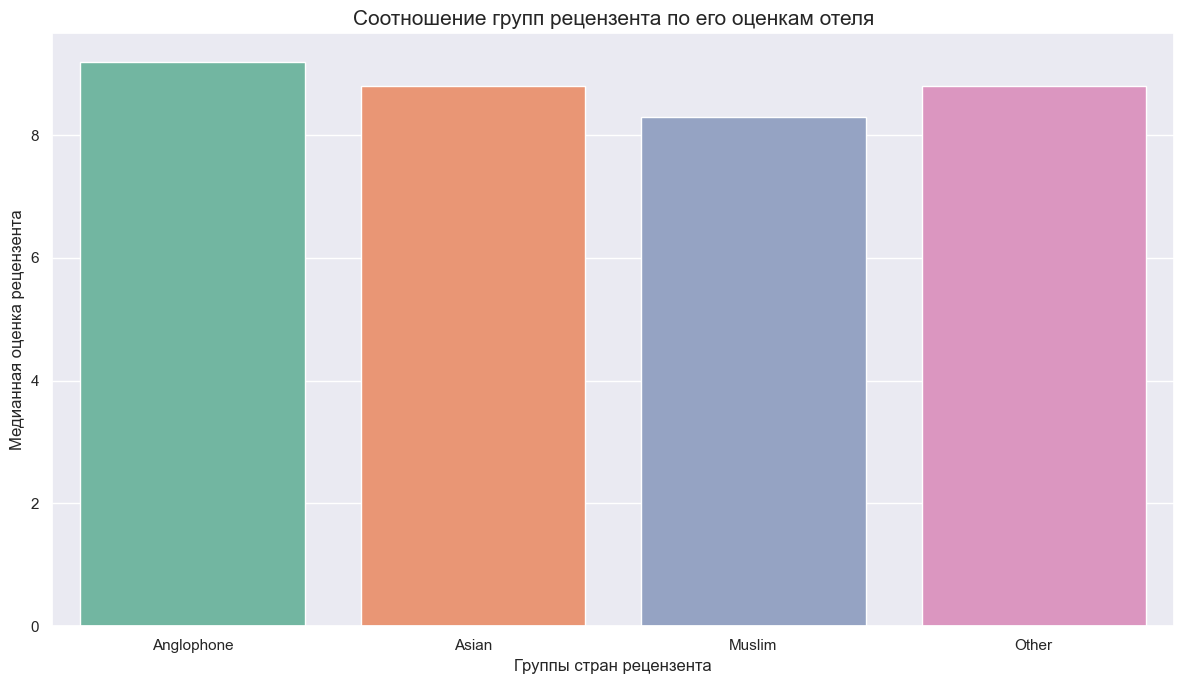

In [30]:
# Медианная оценка рецензента сгрупперованная по новым признакам
pivot = hotels.groupby(['reviewer_country_group'],
                       observed=True)['reviewer_score'].median().to_frame().reset_index()

# Визуализируем 
plt.figure(figsize=(12,7))
sns.barplot(pivot,
            x='reviewer_country_group',
            y='reviewer_score',
            palette=palette)
plt.title("Соотношение групп рецензента по его оценкам отеля", fontsize=15)
plt.xlabel("Группы стран рецензента")
plt.ylabel("Медианная оценка рецензента")
plt.tight_layout()
plt.show()

In [31]:
hotels.groupby(['reviewer_country_group'],
                       observed=True)['reviewer_score'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
reviewer_country_group,,,,,,,,
Anglophone,259024.0,8.52,1.59,2.5,7.5,9.2,10.0,10.0
Asian,9254.0,8.28,1.62,2.5,7.5,8.8,9.6,10.0
Muslim,36345.0,7.96,1.82,2.5,7.1,8.3,9.6,10.0
Other,81873.0,8.23,1.65,2.5,7.5,8.8,9.6,10.0


**Выводы:**
-   Наибольшее количество отзывов оставлено рецензентами из англоязычных стран (259,024), что значительно превышает другие группы
-   Самые высокие оценки в среднем ставят англоязычные рецензенты (медиана 9.2, среднее 8.52)
-   Самые низкие оценки характерны для рецензентов из мусульманских стран (медиана 8.3, среднее 7.96)
-   Наибольший разброс оценок наблюдается в группе мусульманских стран (std=1.82 против 1.59-1.65 у других групп)
-   Азиатские рецензенты демонстрируют сдержанное оценивание (медиана 8.8), близкое к группе "Other"
-   Все группы используют весь диапазон оценок от минимальных 2.5 до максимальных 10.0
-   75-й процентиль у всех групп, кроме англоязычных, не превышает 9.6, тогда как англоязычные чаще ставят 10.0
-   визуально минимальные отличия есть, но статитстически ли они значими?

###  **Средняя оценка рецензента статистически значимо различаются в зависимости от национальной группы?**

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Средняя оценка рецензента не различается в зависимости от национальной группы Anglophone ($μ_1$), Asian ($μ_12$), Muslim ($μ_3$), Other ($μ_4$)

$$ H_0 : μ_1 = μ_2 = μ_3 = μ_4$$

*Альтернативная гипотеза* ($H_1$): Средняя оценка рецензента различается в зависимости от национальной группы Anglophone ($μ_1$), Asian ($μ_12$), Muslim ($μ_3$), Other ($μ_4$)

$$ H_1 : μ_1 \neq  μ_2 \neq  μ_3 \neq μ_4$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [32]:
# группы рецензиста 
group_anglophone = hotels[hotels['reviewer_country_group'] == 'Anglophone']['reviewer_score']
group_asian = hotels[hotels['reviewer_country_group'] == 'Asian']['reviewer_score']
group_muslim = hotels[hotels['reviewer_country_group'] == 'Muslim']['reviewer_score']
group_other = hotels[hotels['reviewer_country_group'] == 'Other']['reviewer_score']


print("Тест для группы Anglophone:")
result = stats.shapiro(group_anglophone)
decision_normality(result[1])

print("Тест для группы Asian:")
result = stats.shapiro(group_asian)
decision_normality(result[1])

print("Тест для группы Muslim:")
result = stats.shapiro(group_muslim)
decision_normality(result[1])

print("Тест для группы Other:")
result = stats.shapiro(group_other)
decision_normality(result[1])



Тест для группы Anglophone:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Тест для группы Asian:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Тест для группы Muslim:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Тест для группы Other:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Оценка рецензиста»? — Количественный.
* Сколько сравниваемых групп? — Четыре.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет. 

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [33]:
_, p = stats.kruskal(group_anglophone, group_asian, group_muslim, group_other)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод:**
-   Средняя оценка рецензента статистически значимо различаются в зависимости от национальной группы

> **Рассмотрим призанак *hotel_city* - город отеля:**

Для городов отелей воспользуемся внешним источником данных и узнаем является ли столицей страны отеля


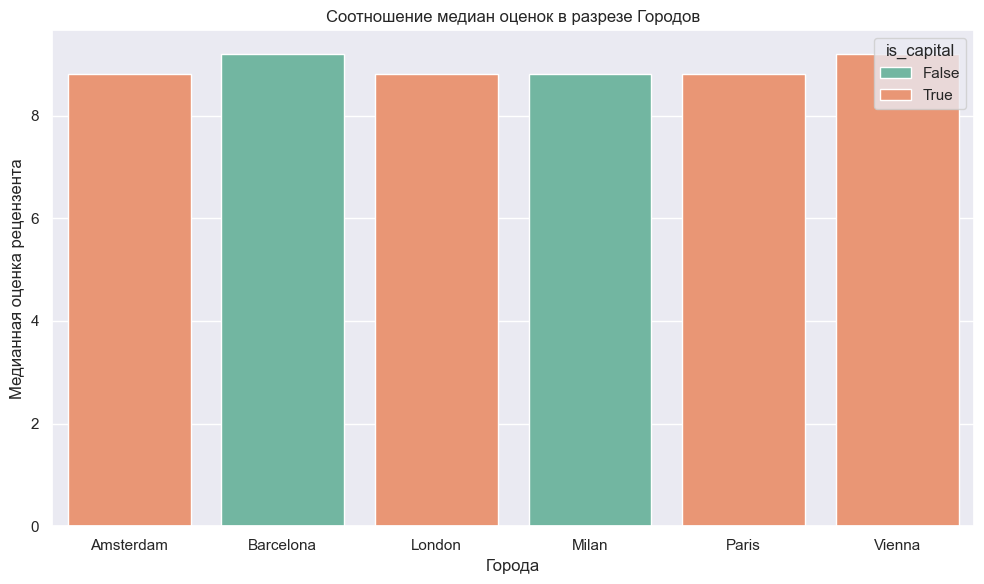

In [34]:
# список город не явсляющихся столицей 
not_capitals = ['Barcelona', 'Milan']

# создаем признак находится ли отель в столице страны
hotels['is_capital'] = hotels['hotel_city'].apply(
    lambda x: False if x in not_capitals else True).astype('category')

hotels_capital_city = hotels.groupby(['hotel_city','is_capital'],
                                observed=True)['reviewer_score'].median().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(
    data=hotels_capital_city,
    x='hotel_city', 
    y='reviewer_score',
    hue='is_capital',
    palette=palette)
plt.title("Соотношение медиан оценок в разрезе Городов")
plt.xlabel("Города")
plt.ylabel("Медианная оценка рецензента")

plt.tight_layout()

In [35]:
hotels.groupby(['hotel_city','is_capital'],
               observed=True)['reviewer_score'].describe().round(2)

,,count,mean,std,min,25%,50%,75%,max
hotel_city,is_capital,,,,,,,,
Amsterdam,True,43004.0,8.45,1.60,2.5,7.5,8.8,9.6,10.0
Barcelona,False,45132.0,8.55,1.56,2.5,7.9,9.2,9.6,10.0
London,True,196773.0,8.33,1.67,2.5,7.5,8.8,9.6,10.0
Milan,False,27882.0,8.36,1.64,2.5,7.5,8.8,9.6,10.0
Paris,True,44528.0,8.42,1.65,2.5,7.5,8.8,9.6,10.0
Vienna,True,29177.0,8.55,1.51,2.5,7.9,9.2,9.6,10.0


Никакой зависимости не обнаруженно, признак неинформативен

> **Рассмотрим признаки *negative_review* и *positive_review***

**Напоминание:**
-   *negative_review* — Отрицательный отзыв, который рецензент дал отелю (текст).
-   *positive_review* — Положительный отзыв, который рецензент дал отелю (текст).

**Задача:**
-   Постараемся классифицировать признаки и выявить полезные (сильные) признаки.

Негативный отзыв и положительный отзыв - это два важнейших признака, из которых можно извлечь ценную информацию. Есть несколько вариантов подходов для извлечения *gold information*:
-   Поиск зависимостей, написание функций отбора и классификации 
-   Использование алгоритма анализа настроений вейдера (однако, как окажется дальше требуется дополнительная обработка)
-   Комбинирование первых двух пунктов.

Для начала изучим данные, посмотрим частоты, что очень важно для нашего исследования. Придумывать машину мы не будем, постараемся найти оптимальный вариант - будем комбинировать и импровизировать. 


In [36]:
# Уберем лишние пробелы и приведем к единому регистру негативные отзывы
hotels.negative_review = hotels.negative_review.str.lower().str.strip()

# Уберем лишние пробелы и приведем к единому регистру положительные отзывы
hotels.positive_review = hotels.positive_review.str.lower().str.strip()

In [37]:
# Рассмотрим частоты негативных отзывов
most_common_neg = hotels.negative_review.value_counts().to_frame().reset_index()
most_common_neg[most_common_neg['count'] > 5][:20]



,negative_review,count
0,no negative,95833
1,nothing,15874
2,n a,1392
3,none,1115
4,,606
5,nothing really,493
6,small room,424
7,all good,419
8,breakfast,396
9,location,392


Можем заметить интересную особенность в данных в признаке отрицательного отзыва имеются приличное кооличество положительных отзывов, то есть следует создать признак мигалку, котрая будет сигнализировать, что вовсе негативный отзыв не является таким.

Проанализировав все слова составим датасет с отзывами, которые будут признаком опровержения негативного отзыва.

Датасет я подготовил заранее: `data/no_negative_reviews.csv`

In [38]:
# Рассмотрим частоты позитивных отзывов
most_common_pos = hotels.positive_review.value_counts().to_frame().reset_index()
most_common_pos[most_common_pos['count'] > 5][:20]




,positive_review,count
0,no positive,26863
1,location,8831
2,everything,2453
3,nothing,1295
4,great location,1289
5,the location,1185
6,good location,1122
7,breakfast,591
8,friendly staff,544
9,excellent location,476


Тоже есть случаи когда позитивный отзыв не является таким, но таких случаев гораздо меньше. Также проживающим часто нравилось местоположение: *location*, что подталкивает к углублению в этот вопрос. 

Рассмотрев еще больше подробнее можно заметить что в основном все хвалят:
-   location/place
-   staff
-   bad
-   breakfast
-   clean

Воспользуемся алгоритмом вейдера и создадим на его основе новые признаки 

In [39]:

# def vader_sentiment_analysis(df, targ_col):
#    """Функция для формирования датафрейма с определением тональности текста
#       по алгоритму Вейдера.
   
#    Args:
#        df (pd.DataFrame): incoming df
#        targ_col (str): target column

#    Returns:
#        pd.DataFrame: df with neg, neu, pos, compound from Vader.
       
#        looks like:
#        __|targ_col_neg|targ_col_neu|targ_col_pos|targ_col_comp|
#        0 |         0.1|         0.8|         0.2|         0.64|
#        etc.
#    """
   
   
#    # Инит класса.
#    sia = SentimentIntensityAnalyzer()
#    # Словарь для записи результатов.
#    res = {}
   
#    # Цикл по строкам датафрейма и запись анализа настроения в словарь.
#    for i, text in enumerate(tqdm(df[targ_col], total=len(df))):
#        res[i] = sia.polarity_scores(text)
   
#    # Переименование столбцов.
#    new_columns = {col: f"{targ_col}_{col}" for col in res[0].keys()}
#    # Возврат датафрейма с решением и переименованием столбцов.
#    return pd.DataFrame(res).T.rename(columns=new_columns)

# # вызов функции и создание новых датафреймов с новыми признаками вейдера 
# df_neg = vader_sentiment_analysis(hotels, 'negative_review')
# df_pos = vader_sentiment_analysis(hotels, 'positive_review')

# # сохранение в csv файлы 
# df_neg.to_csv('data/new_neg_columns.csv', encoding='utf-8')
# df_pos.to_csv('data/new_pos_columns.csv', encoding='utf-8')


После обработки функцией *vader_sentiment_analysis* мы получаем 8 числовых признаков (по 4 для негативных и позитивных отзывов), которые отражают эмоциональную окраску текстов. Давайте познакомимся с каждым из них.
1. *Признаки связанные с негативным отзывом:*
    -   *negative_review_neg*  — Доля негативных слов в отзыве.
    -   *negative_review_neu*  — Доля нейтральных слов
    -   *negative_review_pos*  —  Доля позитивных слов, даже в негативном отзыве.
    -   *negative_review_compound*  — Итоговая оценка тональности негативного отзыва
    
2. *Признаки связанные с позитивным отзывом:*
    -   *positive_review_neg*  — Доля положительных слов в отзыве.
    -   *positive_review_neu*  — Доля нейтральных слов
    -   *positive_review_pos*  —  Доля негативных слов, даже в положительном отзыве.
    -   *positive_review_compound*  — Итоговая оценка тональности позитивного отзыва


Добавим новые признаки в нашу исходную таблицу 

Text(0.5, 1.0, 'Корреляция новых принаков вместе с целевой переменной')

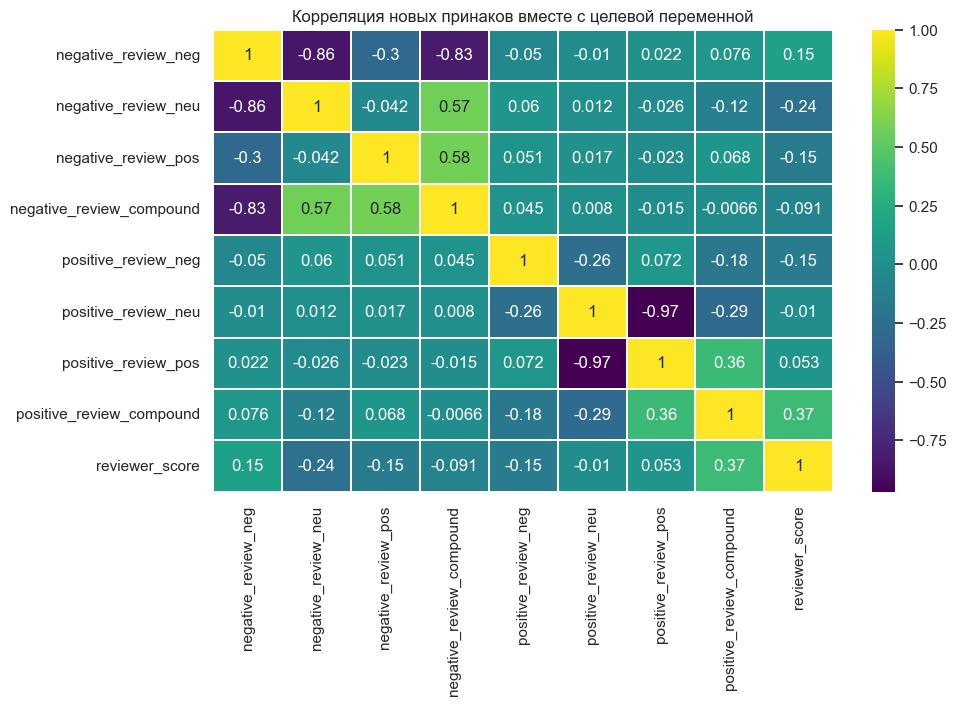

In [40]:
# считаем данные с таблиц 
df_neg = pd.read_csv('data/new_neg_columns.csv', encoding='utf-8', index_col='Unnamed: 0').reset_index(drop=True)
df_pos = pd.read_csv('data/new_pos_columns.csv', encoding='utf-8', index_col='Unnamed: 0').reset_index(drop=True)
hotels = hotels.reset_index(drop=True)  


# Объединение результатов
hotels = pd.concat([hotels, df_neg, df_pos], axis=1)


cols = df_neg.columns.to_list() + df_pos.columns.to_list() + ['reviewer_score']

# корреляция с целевой переменной по новым признакам
plt.figure(figsize=(10,6))
sns.heatmap(hotels[cols].corr(method='spearman'),
            annot=True,
            linewidths=0.1, 
            cmap='viridis',
            fmt='.2g')
plt.title("Корреляция новых принаков вместе с целевой переменной")

Можем заметить, что корреляция признака `*negative_review_compound*` - итоговая оценка тональности негативного отзыва слабо коррелирует с reviewer_score - это означает, что в действительности большинство негативных отзывов вовсе не являются такими и стоит обратить на это внимание.

Как можем заметить алгоритм вейдера не совсем точен и плохо оценивает `no negative` ,  `no positive` и другие. Стоит обрабортать эти случаи.

In [41]:
cols = df_neg.columns.to_list() + df_pos.columns.to_list()
hotels[cols].describe()

,negative_review_neg,negative_review_neu,negative_review_pos,negative_review_compound,positive_review_neg,positive_review_neu,positive_review_pos,positive_review_compound
count,386496.000000,386496.000000,386496.000000,386496.000000,386496.000000,386496.000000,386496.000000,386496.000000
mean,0.322475,0.619195,0.052948,-0.208915,0.034798,0.576403,0.388230,0.593357
std,0.410256,0.392902,0.115742,0.453393,0.103344,0.273874,0.235532,0.342519
min,0.000000,0.000000,0.000000,-0.998200,0.000000,0.000000,0.000000,-0.983200
25%,0.000000,0.000000,0.000000,-0.709600,0.000000,0.408000,0.229000,0.343300
50%,0.107000,0.781000,0.000000,-0.177900,0.000000,0.588000,0.404000,0.708900
75%,0.855000,1.000000,0.057000,0.000000,0.000000,0.752000,0.588000,0.883400
max,1.000000,1.000000,1.000000,0.996400,1.000000,1.000000,1.000000,0.999200


Максимальную корреляцию с целевой переменной *reviewer_score* составляет признак *positive_review_compound* $= 0.37$

На основе новых признаков попробуем создать более сильные признаки. Можно заметить, что в *positive_review_compound* минимальное значение - -0.983200 (алгоритм утверждает что в позитивных отзывах есть негативный отзыв) так и наоборот со столбцом *negative_review_compound*.

Как было выясненно выше, есть особенность в данных, где сущность таких признаков как *negative_review* и *positive_review* совершенно противоположна пониманию признака. Давайте рассмотрим строчки, где отзыв является противопоставлением сущности признака, а также как алгоритм вейдера оценивает его.

In [42]:
# удаляем сильно коррелирующий признак 
hotels.drop('positive_review_neu', axis=1, inplace=True)

Вручную я собрал негативные *антонимы* (так скажем) - они представленны в датасете `data/no_negative_review.csv`

Посмотрим как алгоритм вейдера оценивает их!

In [43]:
# считываем файл 
no_negative_reviews = pd.read_csv('data/no_negative_reviews.csv')

sia = SentimentIntensityAnalyzer()

vender_negative_reviews = []
vender_neutral_reviews = []
# перебираем все отзывы и оцениваем их с помощью алгоритма вендера
for review in no_negative_reviews['non_negative_reviews'].values:
    # значение словаря по ключу 'compound' - коэффицент тональности
    res = sia.polarity_scores(review)['compound']
    
    if res >= 0.05: # положительный отзыв (верно обработал алгоритм)
        continue
    elif res <= -0.05: # алгоритм отработал неправильно
        vender_negative_reviews.append(review)
    else:
        # алгоритм положиительным отзывам придал нейтральное значение
        vender_neutral_reviews.append(review) 
        
    
print(f"Количество тестовых негативных отзывов по вейдеру: {len(vender_negative_reviews)}")
print(f"Первые пять негативных отзывов:\n{'; '.join(vender_negative_reviews[:5])}", end='\n\n')

print(f"Количество тестовых нейтральных отзывов по вейдеру: {len(vender_neutral_reviews)}")
print(f"Первые пять нейтральных отзывов:\n{'; '.join(vender_neutral_reviews[:5])}")

Количество тестовых негативных отзывов по вейдеру: 74
Первые пять негативных отзывов:
no negative; no complaints; nothing all good; having to leave; nothing everything was perfect

Количество тестовых нейтральных отзывов по вейдеру: 70
Первые пять нейтральных отзывов:
nothing; n a; none; ''; nothing really


Как видим алгоритмс вейдера - это хороший и доступный инструмент, однако он не идеален. Так и получается, что положительные отзывы он отнес к негативным и, соответсвенно, наоборот.

`Стоит написать обработчик чтобы обработать эти исключения и так скажем помочь ему.`

> **Дальше будет представленно два хода решения поставленной задачи.**
-   Первая - простейшая классификация на слово антоним 
-   Вторая - классификация на группы 
-   Создание новой шкалы тональности отзыва


### *Разберемся с негативными отзывами*

Рассмотрим аномалии в данных, рецензент написал что нет ничего плохого, но при этом поставил плохой отзыв.

Почему это аномалия? рецензент у которого в действительности нет никаких претензий к отелю он оставляет к примеру отзыв `no negative`, и при этом оставляет плохую оценку. Это точно будет сбивать модель.

In [44]:
mask1 = hotels['negative_review'].isin(no_negative_reviews.iloc[:, 0])
mask2 = hotels['reviewer_score'] < 5
display(hotels.loc[mask1, 'reviewer_score'].describe())

# избавляемся от выбросов (они будут мешать предсказанию)
hotels = hotels.drop(hotels[mask1 & mask2].index, axis=0).reset_index(drop=True)

count    122876.000000
mean          9.392031
std           0.892182
min           2.500000
25%           9.200000
50%           9.600000
75%          10.000000
max          10.000000
Name: reviewer_score, dtype: float64

**Способ первый**

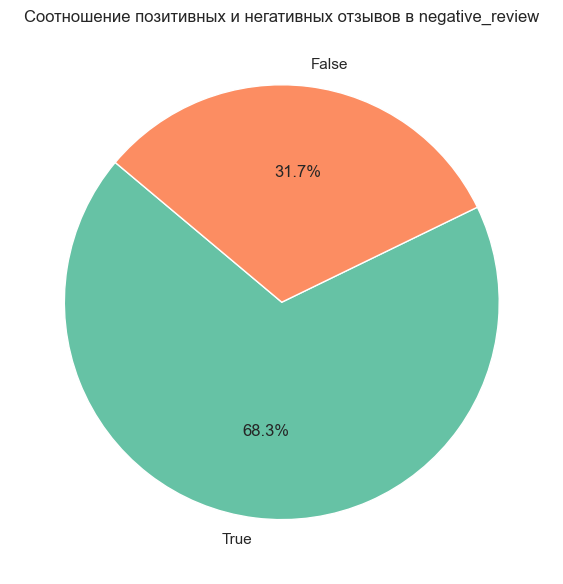

In [45]:
# Функция маячок для классификации негативного отзыва 
def is_real_negative_review(review):

    if review in no_negative_reviews.non_negative_reviews.values:
        return False # положительный отзыв
    else:
        return True # негативный отзыв

# создание нового признака 
hotels['is_real_negative_review_category'] = hotels['negative_review'].apply(is_real_negative_review)
hotels['is_real_negative_review_category'] = hotels['is_real_negative_review_category'].astype('category')

counts = hotels['is_real_negative_review_category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels = counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=palette,
)
plt.title("Соотношение позитивных и негативных отзывов в negative_review")
plt.tight_layout()


**Выводы:**
-   32% негативных отзывов не являются таковыми
-   68% действительно негативные

**Второй способ:**

Создадим более продвинутую функцию, понятное дело не все *антонимы были записаны в датасете no_negative_reviews* поэтому создадим шкалу оценки негативного отзыва от -1 до 1 

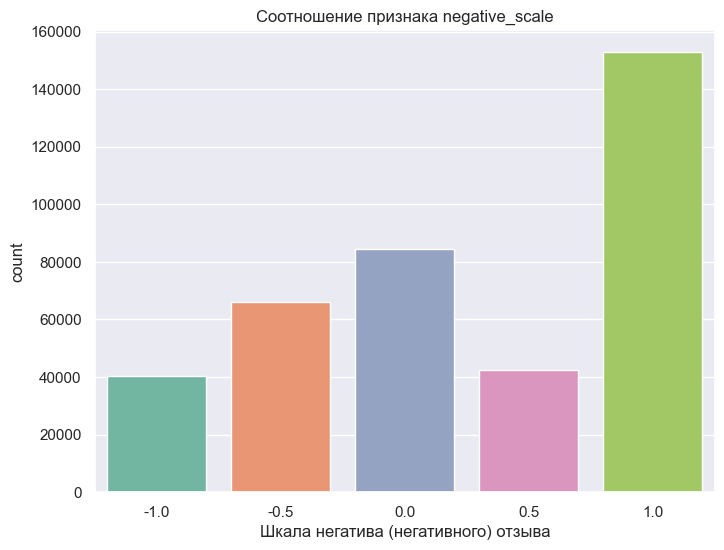

In [46]:
# Функция маячок для классификации негативного отзыва
def negative_scale(review, koff):
    
    # если это отзыв антоним
    if review in no_negative_reviews['non_negative_reviews'].values:
        return 1
        
    if koff >= 0.05: # положительный отзыв 
        # если отзыв средний, в большую сторону положительный
        if koff < 0.5:
            return 0.5
        # отзыв очень положительный
        elif koff >= 0.5:
            return 1

    if koff <= -0.05: # отрицательный отзыв
        # если отзыв отрицательный, но не чтобы там была ругань брань и так далее
        if koff > -0.5:
            return -0.5
        # отзыв очень негативный
        elif koff <= -0.5:
            return -1
        
    # оставлен нейтральный отзыв
    return 0

# создаем новый признак
hotels['negative_scale'] = hotels.apply(
    lambda row: negative_scale(
        row['negative_review'], 
        row['negative_review_compound']
    ), 
    axis=1
)

# Строим столбчатую диаграмму
plt.figure(figsize=(8,6))
sns.countplot(data=hotels,
             x='negative_scale',
             palette=palette)
plt.xlabel("Шкала негатива (негативного) отзыва")
plt.title("Соотношение признака negative_scale")
plt.show()


**Третий Способ:**

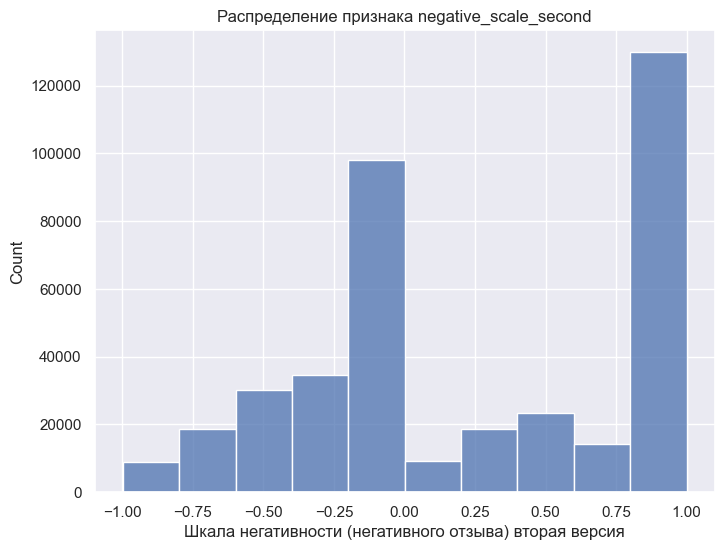

In [47]:
# Функция маячок для создание шкалы негативного отзыва 
def negative_scale_second(review, koff):
    # если слово антоним 
    if review in no_negative_reviews.non_negative_reviews.values:
        return 1
    
    else: # в остальных случаях полагаемся на алгоритм
        if koff >= 0.05:
            return koff
        elif koff <= -0.05:
            return koff
        else:
            return 0


# создаем новый признак
hotels['negative_scale_second'] = hotels.apply(
    lambda row: negative_scale_second(
        row['negative_review'], 
        row['negative_review_compound']
    ), 
    axis=1
)

# Строим гистограмму диаграмму
plt.figure(figsize=(8,6))
sns.histplot(data=hotels,
             x='negative_scale_second',
             palette=palette,
             bins=10)
plt.xlabel("Шкала негативности (негативного отзыва) вторая версия")
plt.title("Распределение признака negative_scale_second")
plt.show()

#### **Рассмотрим корреляцию между созданными признаками и целевой переменной**


<Axes: >

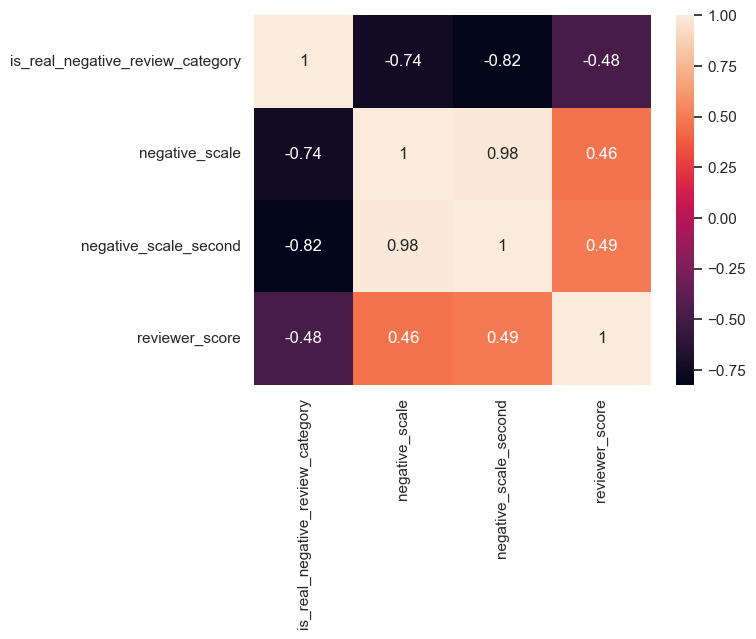

In [48]:
sns.heatmap(hotels[[
    "is_real_negative_review_category", 
    "negative_scale",
    'negative_scale_second',
    'reviewer_score'
]].corr('spearman'), annot=True)

### *Разберемся с позитивными отзывами*

Давайте теперь рассмотрим положительные отзывы. Как мы уже поняли ситуация примерно схожая, но в меньших масштабах. Гораздо меньше слов *антонимов*. 

In [49]:
# список *анонимов* - противопоставляющие сущности признака
negative = ['no positive', 'nothing', 'none', 'all was bad', 'not much']

mask1 = hotels['positive_review'].isin(negative)
mask2= hotels['reviewer_score'] > 8
display(hotels[mask1]['reviewer_score'].describe())

# удаляем аномалии
hotels = hotels.drop(hotels[mask1 & mask2].index, axis=0).reset_index(drop=True)

count    28241.000000
mean         6.732874
std          2.035662
min          2.500000
25%          5.000000
50%          7.100000
75%          8.300000
max         10.000000
Name: reviewer_score, dtype: float64

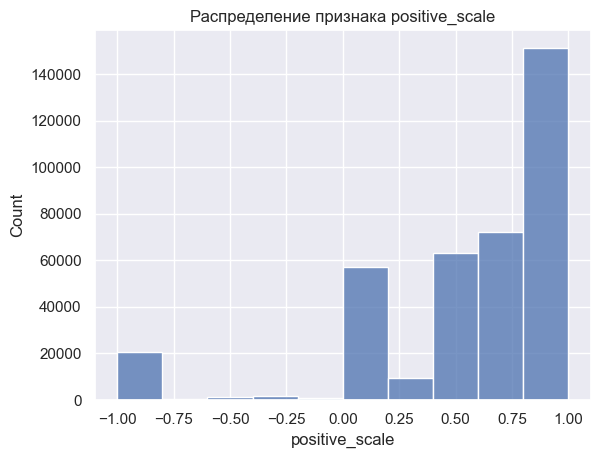

In [50]:
# Функция маячок для классификации положительного отзыва
def positive_scale(review, koff):
    negative = ['no positive', 'nothing', 'none', 'all was bad', 'not much']
    
    if review in negative:
        return -1
    
    # алгоритм 
    if koff >= 0.05: # положительный отзыв
        return koff
    
    elif koff <= -0.05: # негативный отзыв
        return koff
    
    else:
        return 0


# создаем новый признак
hotels['positive_scale'] = hotels.apply(
    lambda row: positive_scale(
        row['positive_review'], 
        row['positive_review_compound']
    ), 
    axis=1
)

# Строим столбчатую диаграмму
sns.histplot(data=hotels,
             x='positive_scale',
             palette=palette,
             bins=10)

plt.title("Распределение признака positive_scale")
plt.show()

In [51]:
hotels.positive_scale.describe()

count    377993.000000
mean          0.528895
std           0.495330
min          -1.000000
25%           0.401900
50%           0.718400
75%           0.886000
max           0.999200
Name: positive_scale, dtype: float64

> ### **СОЗДАНИЕ СИЛЬНЕЙШЕГО ПРИЗНАКА**

*Вариант 1: Объединение без нормализации*

In [52]:
# Новый признак как разность позитивного и негативного сентимента
hotels['net_sentiment'] = hotels['positive_scale'] - hotels['negative_scale_second']

*Как это работает?*

Разность: Вычитаем значение негативного сентимента из позитивного:
-   Если результат положительный (например, 1 - (-1) = 2), это указывает на сильный позитивный сентимент.
-   Если результат отрицательный (например, -1 - 1 = -2), это указывает на сильный негативный сентимент.
-   Если результат близок к нулю (например, 1 - 1 = 0), сентимент нейтральный.

Разность подчёркивает "чистый" сентимент, усиливая различия между позитивными и негативными отзывами.

*Вариант 2: Объединение с нормализацией*


In [53]:
from sklearn.preprocessing import MinMaxScaler

# Инициализация MinMaxScaler для нормализации в диапазон [0, 1]
scaler = MinMaxScaler()

# Нормализация каждого признака
hotels['norm_positive'] = scaler.fit_transform(hotels[['positive_scale']])
hotels['norm_negative'] = scaler.fit_transform(hotels[['negative_scale_second']])

# Новый признак как разность нормализованных значений
hotels['net_sentiment_normalized'] = hotels['norm_positive'] - hotels['norm_negative']

*Как это работает?*
1. Нормализация: Используем MinMaxScaler, чтобы преобразовать оба признака из диапазона [-1, 1] в [0, 1]:
    -   Например, -1 становится 0, 0 становится 0.5, а 1 становится 1.

2. Разность: Вычитаем нормализованный негативный сентимент из нормализованного позитивного.

3. Диапазон: Новый признак net_sentiment_normalized будет в диапазоне от -1 до 1:
    -   1 (например, 1 - 0) — сильный позитив.
    -   -1 (например, 0 - 1) — сильный негатив.
    -   0 — нейтральный сентимент.

<Axes: >

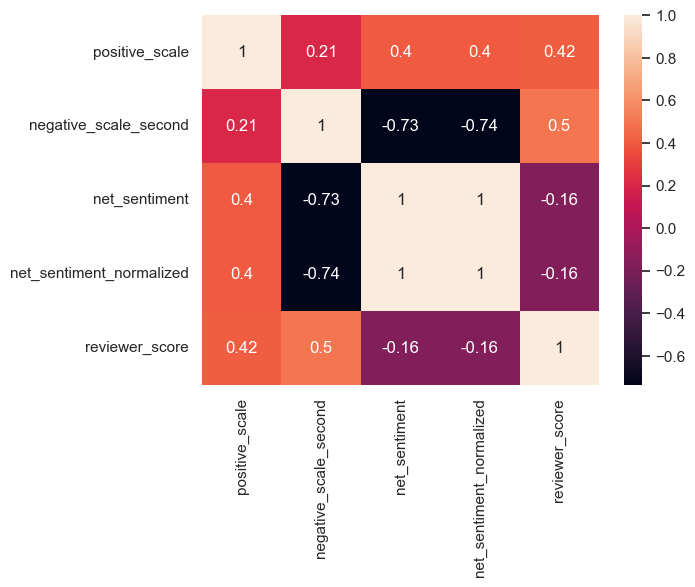

In [54]:
sns.heatmap(hotels[[
    'positive_scale',
    'negative_scale_second',
    'net_sentiment',
    'net_sentiment_normalized',
    'reviewer_score'
]].corr('spearman'), annot=True)

In [55]:
# удаляем нормализованные призаки 
hotels.drop(['norm_positive', 'norm_negative'], axis=1, inplace=True)

### *Создаем признак как взвешанную сумму с подбором весов*

Так как влияние негативного и позитивного отзыва может быть разной на оценку рецензента, подберем веса.

In [56]:
# Подберем самые лучшие веса
best_x = None
best_y = None
best_corr = -1  # Инициализируем минимальной возможной корреляцией


# Значения весов для перебора
x_values = np.arange(0, 1.1, 0.1)
y_values = np.arange(0, 1.1, 0.1)


# Внешний цикл с индикатором прогресса
for x in tqdm(x_values, desc="Подбор весов x"):
    for y in y_values:
        # Создаем новый признак как взвешенную сумму
        hotels['weighted_sentiment'] = x * hotels['positive_scale'] + y * hotels['negative_scale_second']
        
        # Вычисляем корреляцию Спирмена
        corr = hotels[['weighted_sentiment', 'reviewer_score']].corr(method='spearman').iloc[0, 1]
        
        # Если текущая корреляция лучше, обновляем значения
        if corr > best_corr:
            best_corr = corr
            best_x = x
            best_y = y

# Выводим результаты
print("Лучшие веса: x = {:.2F}, y = {:.2F}, корреляция = {:.2F}".format(best_x, best_y, best_corr))

Подбор весов x:   0%|          | 0/11 [00:00<?, ?it/s]

Лучшие веса: x = 0.30, y = 0.30, корреляция = 0.59


Text(0.5, 1.0, 'Корреляция целевой перемнной с новыми признаками')

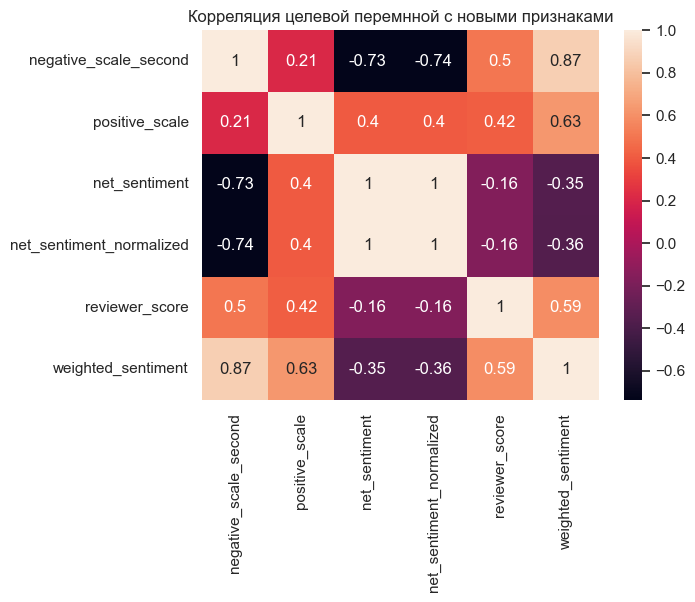

In [57]:
sns.heatmap(hotels[['negative_scale_second',
                 'positive_scale',
                 'net_sentiment',
                 'net_sentiment_normalized',
                 'reviewer_score',
                 'weighted_sentiment']].corr('spearman') , annot=True, )
plt.title("Корреляция целевой перемнной с новыми признаками")

### *Отклонение от средней по названию отелей*

Еще один признак, который следует создать отклонение от средней по названию отеля. Можно было бы сделать с *avarage score*, однако информации по этому признаку не так много, насколько стоит ему доверять - сомнительно. Ну а также утверждение, что оценки постояльцев должны быть соответсвовать средним баллам отеля за последний комментарий прошлого года - точно сомнительно. После можно, так скажем, выдвинуть утверждение, что признак усилится если довать еще группировку по году/сезону.

**Напоминание о признаках:**
-   *negative_scale_second* и *positive_scale*: Эти признаки представляют собой шкалы сентимента (диапазон от -1 до 1), отражающие тональность негативных и позитивных отзывов. Они уже были нормализованы, но нормализация не повлияла на их корреляцию с целевой переменной reviewer_score.

**О чем идет речь?**

Я думаю всем понятно, что в реальной жизни при выборе отеля мы смотрим на отзывы отеля, их значимость чаще всего определяет балл, который выставил постоялец. Понятое дело, если в отеле действительно плохо, то и оценки постоялцев будут первым из ориентиров уровня отеля. Но мы же не будем смотреть на все отзывы отеля, а что если их 100, 200 и так далее. Поэтому придумали оценивание отелей, исходя из отзывов, я предполагаю это среднее значение - именно на него в первую очередь смотрит потенциальный постоялец.  

**В чем заключается задумка?**

1. Мы будем группировать данные по названию отелей после смотреть значение признаков *negative_scale_second* и *positive_scale*. 
2. Посчитаем *выборочное среднее* в нашем случае воспользуемся мерой центральной тенденции как медианна и создадим новые признаки.
3. Посчитаем для каждого отзыва отклонение от выборочного среднего отеля



**Шаг 1: Группировка по отелям и вычисление меры центральной тенденции**

In [58]:
# Группировка по отелям и вычисление медианы для каждого признака
hotel_means = hotels.groupby('hotel_name')[['negative_scale_second', 'positive_scale']].median()

# Переименуем столбцы для ясности
hotel_means = hotel_means.rename(columns={
    'negative_scale_second': 'mean_negative_review_scale',
    'positive_scale': 'mean_positive_review_scale'
}).reset_index()

display(hotel_means)

# Присоединяем медианы к основному датасету
hotels = hotels.merge(hotel_means, on='hotel_name', how='left')

,hotel_name,mean_negative_review_scale,mean_positive_review_scale
0,11 Cadogan Gardens,0.52680,0.78755
1,1K Hotel,0.00000,0.62490
2,25hours Hotel beim MuseumsQuartier,0.50225,0.82250
3,41,1.00000,0.85550
4,45 Park Lane Dorchester Collection,1.00000,0.58590
...,...,...,...
1487,citizenM London Bankside,0.50760,0.79640
1488,citizenM London Shoreditch,0.49810,0.80720
1489,citizenM Tower of London,0.40190,0.80740
1490,every hotel Piccadilly,0.66170,0.73510


**Шаг 2: Вычисление отклонений**

In [59]:
# Отклонение от медианы для каждого признака
hotels['deviation_negative_review_scale'] = hotels['negative_scale_second'] - hotels['mean_negative_review_scale']
hotels['deviation_positive_review_scale'] = hotels['positive_scale'] - hotels['mean_positive_review_scale']

In [60]:
hotels[hotels.hotel_name == '11 Cadogan Gardens'][[
    'negative_scale_second',
    'positive_scale',
    'mean_negative_review_scale',
    'mean_positive_review_scale',
    'reviewer_score']]

,negative_scale_second,positive_scale,mean_negative_review_scale,mean_positive_review_scale,reviewer_score
8234,1.0000,0.9303,0.5268,0.78755,10.0
10320,1.0000,0.9018,0.5268,0.78755,10.0
19224,0.0000,0.9312,0.5268,0.78755,9.6
34439,1.0000,0.0000,0.5268,0.78755,10.0
34533,1.0000,0.9741,0.5268,0.78755,9.6
...,...,...,...,...,...
366465,1.0000,0.5574,0.5268,0.78755,10.0
370222,1.0000,0.5859,0.5268,0.78755,10.0
374252,1.0000,0.0000,0.5268,0.78755,6.7
374314,1.0000,0.8748,0.5268,0.78755,10.0


**Шаг 3: Смотрим корреляцию**

Text(0.5, 1.0, 'Корреляция целевой перемнной с новыми признаками')

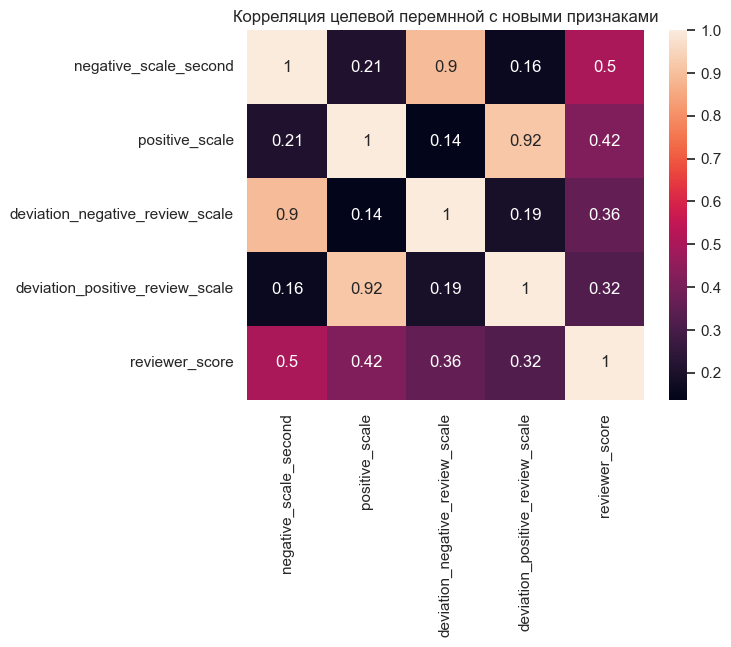

In [61]:
sns.heatmap(hotels[['negative_scale_second',
                    'positive_scale',
                    'deviation_negative_review_scale',
                    'deviation_positive_review_scale',
                    'reviewer_score']].corr('spearman'), annot=True)
plt.title("Корреляция целевой перемнной с новыми признаками")

К большому сожалею результаты оказать неудовлетворительными, корреляция с целевой переменной стало только меньше. Попробуем усилить признак и посмотреть в динамике.

**Шаг 1: Группировка по отелям и годам и вычисление меры центральной тенденции**

In [62]:
# Группировка по отелям и вычисление медианы для каждого признака
hotel_year_means = hotels.groupby(['hotel_name',
                                   'review_year'])[['negative_scale_second',
                                                    'positive_scale']].mean()

# Переименуем столбцы для ясности
hotel_year_means = hotel_year_means.rename(columns={
    'negative_scale_second': 'mean_negative_review_year_scale',
    'positive_scale': 'mean_positive_review_year_scale'
}).reset_index()

display(hotel_year_means)

# Присоединяем медианы к основному датасету
hotels = hotels.merge(hotel_year_means, on=['hotel_name', 'review_year'], how='left')

,hotel_name,review_year,mean_negative_review_year_scale,mean_positive_review_year_scale
0,11 Cadogan Gardens,2015,0.303075,0.434631
1,11 Cadogan Gardens,2016,0.469267,0.687290
2,11 Cadogan Gardens,2017,0.375466,0.561434
3,1K Hotel,2015,0.013071,0.533768
4,1K Hotel,2016,0.042542,0.402509
...,...,...,...,...
4471,every hotel Piccadilly,2016,0.418233,0.566593
4472,every hotel Piccadilly,2017,0.453507,0.577891
4473,pentahotel Vienna,2015,0.344417,0.511733
4474,pentahotel Vienna,2016,0.256590,0.593519


**Шаг 2: Вычисление отклонений**

In [63]:
# Отклонение от медианы с учетом года
hotels['deviation_negative_review_year_score'] = hotels['negative_scale_second'] - hotels['mean_negative_review_year_scale']
hotels['deviation_positive_review_year_score'] = hotels['positive_scale'] - hotels['mean_positive_review_year_scale']

In [64]:
hotels[hotels.hotel_name == '11 Cadogan Gardens'][['review_year',
                                                   'negative_scale_second',
                                                   'positive_scale',
                                                   'mean_negative_review_year_scale',
                                                   'mean_positive_review_year_scale',
                                                   'reviewer_score']]

,review_year,negative_scale_second,positive_scale,mean_negative_review_year_scale,mean_positive_review_year_scale,reviewer_score
8234,2017,1.0000,0.9303,0.375466,0.561434,10.0
10320,2017,1.0000,0.9018,0.375466,0.561434,10.0
19224,2016,0.0000,0.9312,0.469267,0.687290,9.6
34439,2016,1.0000,0.0000,0.469267,0.687290,10.0
34533,2016,1.0000,0.9741,0.469267,0.687290,9.6
...,...,...,...,...,...,...
366465,2017,1.0000,0.5574,0.375466,0.561434,10.0
370222,2017,1.0000,0.5859,0.375466,0.561434,10.0
374252,2017,1.0000,0.0000,0.375466,0.561434,6.7
374314,2015,1.0000,0.8748,0.303075,0.434631,10.0


**Шаг 3: Смотрим корреляцию**

Text(0.5, 1.0, 'Корреляция целевой перемнной с новыми признаками')

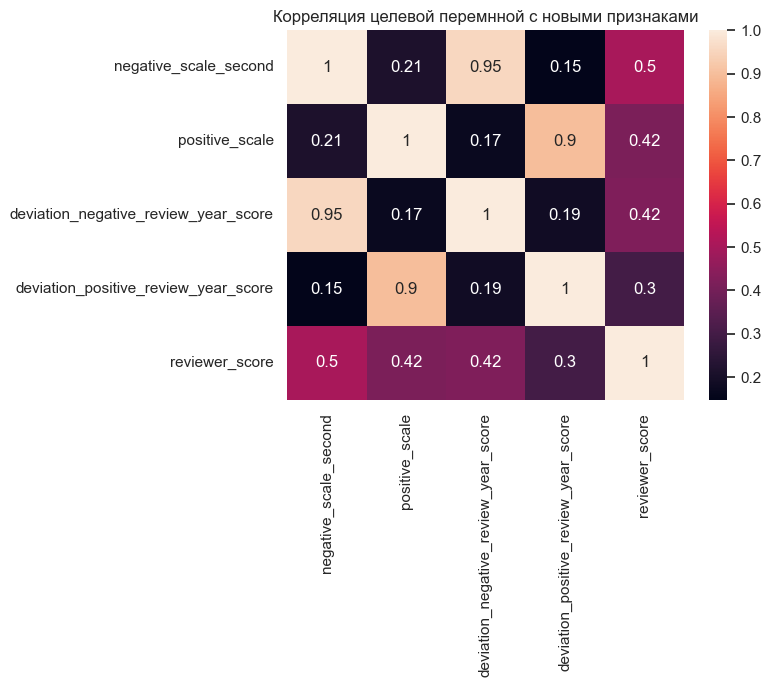

In [65]:
sns.heatmap(hotels[['negative_scale_second',
                    'positive_scale',
                    'deviation_negative_review_year_score',
                    'deviation_positive_review_year_score',
                    'reviewer_score']].corr('spearman'), annot=True)
plt.title("Корреляция целевой перемнной с новыми признаками")

Показатели не изменились, это означает, что в динамике особо не изменялись отзывы в отелях. Следовательно, отели с каждым годом не особо улучшали качество предоставления услуг.

**Шаг 1: Группировка по отелям и cезонам и вычисление меры центральной тенденции**

In [66]:
# Группировка по отелям и вычисление медианы для каждого признака
hotel_season_means = hotels.groupby(['hotel_name',
                                     'review_season'])[['negative_scale_second',
                                           'positive_scale']].mean()

# Переименуем столбцы для ясности
hotel_season_means = hotel_season_means.rename(columns={
    'negative_scale_second': 'mean_negative_review_season_scale',
    'positive_scale': 'mean_positive_review_season_scale'
}).reset_index()

display(hotel_season_means)

# Присоединяем медианы к основному датасету
hotels = hotels.merge(hotel_season_means, on=['hotel_name', 'review_season'], how='left')

,hotel_name,review_season,mean_negative_review_season_scale,mean_positive_review_season_scale
0,11 Cadogan Gardens,Autumn,0.325821,0.564748
1,11 Cadogan Gardens,Spring,0.533865,0.374545
2,11 Cadogan Gardens,Summer,0.404646,0.696332
3,11 Cadogan Gardens,Winter,0.430372,0.736112
4,1K Hotel,Autumn,0.003954,0.516914
...,...,...,...,...
5963,every hotel Piccadilly,Winter,0.531745,0.615881
5964,pentahotel Vienna,Autumn,0.129563,0.641063
5965,pentahotel Vienna,Spring,-0.058292,0.496483
5966,pentahotel Vienna,Summer,0.290027,0.508642


**Шаг 2: Вычисление отклонений**

In [67]:
# Отклонение от медианы с учетом времени года
hotels['deviation_negative_review_season_score'] = hotels['negative_scale_second'] - hotels['mean_negative_review_season_scale']
hotels['deviation_positive_review_season_score'] = hotels['positive_scale'] - hotels['mean_positive_review_season_scale']

**Шаг 3: Смотрим корреляцию**

Text(0.5, 1.0, 'Корреляция целевой перемнной с новыми признаками')

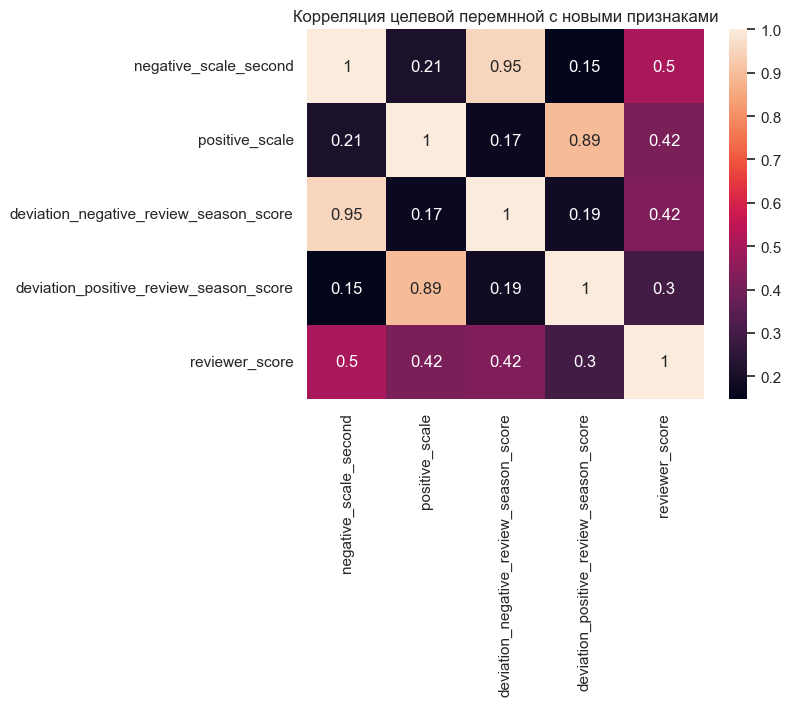

In [68]:
sns.heatmap(hotels[['negative_scale_second',
                    'positive_scale',
                    'deviation_negative_review_season_score',
                    'deviation_positive_review_season_score',
                    'reviewer_score']].corr('spearman'), annot=True)
plt.title("Корреляция целевой перемнной с новыми признаками")

Снова без изменений корреляции.


> **После многочисленных манипуляций создадим итоговый (обобщенный признак).**

        Понравился ли отель постояльцу или нет?

In [69]:
hotels.iloc[:, 25:40].head()

,culture_lto,culture_ind,reviewer_country_group,is_capital,negative_review_neg,negative_review_neu,negative_review_pos,negative_review_compound,positive_review_neg,positive_review_pos,positive_review_compound,is_real_negative_review_category,negative_scale,negative_scale_second,positive_scale
0,60.0,69.0,Anglophone,True,0.000,1.000,0.0,0.0000,0.000,0.655,0.5859,False,1.0,1.0000,0.5859
1,60.0,69.0,Anglophone,True,0.756,0.244,0.0,-0.4767,0.000,0.000,0.0000,True,-0.5,-0.4767,0.0000
2,77.0,24.0,Asian,True,0.423,0.577,0.0,-0.2960,0.379,0.621,0.3400,True,-0.5,-0.2960,-1.0000
3,60.0,69.0,Anglophone,True,1.000,0.000,0.0,-0.7096,0.000,0.721,0.9169,False,1.0,1.0000,0.9169
4,49.0,29.0,Other,True,0.667,0.333,0.0,-0.2500,0.000,0.382,0.8503,True,-0.5,-0.2500,0.8503


In [70]:
def negative_or_positive_review(negative_review,
                                positive_review,
                                total_polarity):
    
    if negative_review in no_negative_reviews.non_negative_reviews.values: # положительный отзыв
        return 1 # Да, очень понравилось
    
    if positive_review in negative:
        return -1 # Нет, очень не понравилось
    
    
    if total_polarity < -0.5:
        return -1 # Нет, очень не понравилось
    
    if  -0.5 <= total_polarity <= -0.1:
        return -0.5 # Нет, не понравилось
    
    if 0.5 <= total_polarity < 1.85:
        return 0.5 # Да, понравилось
    
    if total_polarity >= 1.85:
        return 1 # Да, очень понравилось
    
    return 0 # Не знаю
    

    

# создаем новый признак
hotels['like_hotel'] = hotels.apply(
    lambda row: negative_or_positive_review(
        row['negative_review'], 
        row['positive_review'],
        row['negative_scale_second'] + row['positive_scale']), 
    axis=1
)
    

In [71]:
# так как больше нигде не будем использовать признаки отзывы - удалим их
hotels.drop(['positive_review', 'negative_review'], axis=1, inplace=True)

<Axes: >

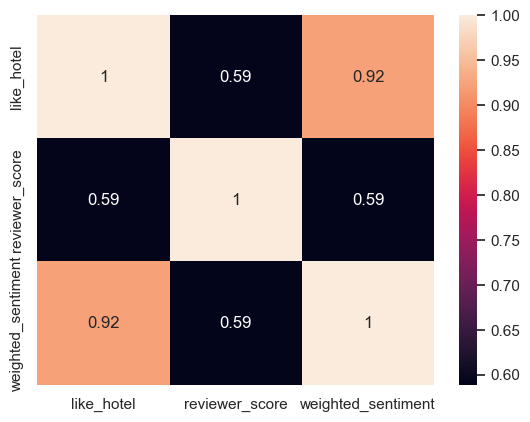

In [72]:
sns.heatmap(hotels[['like_hotel',
                    'reviewer_score',
                    'weighted_sentiment']].corr('spearman'), annot=True)


Создали более сильный признак с корреляцией 0.59

**Создадим категориальный признак уровень популярности отеля**



In [73]:
def categorize_hotel_popularity(df):
    """
    Функция для создания категориального признака популярности отеля на основе количества отзывов.
    
    Параметры:
    - df: DataFrame с данными (hotels).
    
    Возвращает:
    - Series с категориями популярности для каждого отеля.
    """
    # 1. Подсчитываем количество отзывов для каждого отеля
    review_counts = df['hotel_name'].value_counts()
    
    # 2. Определяем квантили для разделения на категории
    quantiles = review_counts.quantile([0.25, 0.5, 0.75])
    q1, q2, q3 = quantiles[0.25], quantiles[0.5], quantiles[0.75]
    
    # 3. Создаем категории на основе квантилей
    def assign_category(count):
        if count >= q3:
            return 'Very Popular'  # Топ-25%
        elif count >= q2:
            return 'Popular'  # 50–75%
        elif count >= q1:
            return 'Average'  # 25–50%
        else:
            return 'Unpopular'  # Нижние 25%
    
    # Применяем категоризацию
    popularity_categories = review_counts.apply(assign_category)
    
    return popularity_categories

In [74]:
# Вычисляем категории популярности
hotel_popularity_categories = categorize_hotel_popularity(hotels)

# Преобразуем в DataFrame для объединения
hotel_popularity_df = hotel_popularity_categories.reset_index()
hotel_popularity_df.columns = ['hotel_name', 'hotel_popularity_category']

# Добавляем категориальный признак в датасет
hotels = hotels.merge(hotel_popularity_df, on='hotel_name', how='left')

# Преобразуем в тип данных category
hotels['hotel_popularity_category'] = hotels['hotel_popularity_category'].astype('category') 

# Проверяем распределение категорий
display(hotels['hotel_popularity_category'].value_counts())

# Смотрим средние значения целевого признака по группам
display(hotels.groupby('hotel_popularity_category')['reviewer_score'].mean())

hotel_popularity_category
Very Popular    246668
Popular          79567
Average          37251
Unpopular        14507
Name: count, dtype: int64

hotel_popularity_category
Average         8.552887
Popular         8.496026
Unpopular       8.451148
Very Popular    8.325848
Name: reviewer_score, dtype: float64

In [75]:
hotels.groupby('hotel_popularity_category')['reviewer_score'].describe()

,count,mean,std,min,25%,50%,75%,max
hotel_popularity_category,,,,,,,,
Average,37251.0,8.552887,1.567081,2.5,7.9,9.2,9.6,10.0
Popular,79567.0,8.496026,1.578599,2.5,7.5,9.2,9.6,10.0
Unpopular,14507.0,8.451148,1.642337,2.5,7.5,8.8,9.6,10.0
Very Popular,246668.0,8.325848,1.661801,2.5,7.5,8.8,9.6,10.0


In [76]:
print(hotels.hotel_popularity_category.unique(), end='\n\n')

# Определяем порядок категорий
popularity_order = ['Unpopular', 'Average', 'Popular', 'Very Popular']

# Применяем ordinal encoding
hotels['hotel_popularity_encoded'] = pd.Categorical(
    hotels['hotel_popularity_category'], 
    categories=popularity_order, 
    ordered=True
).codes

# Проверяем результат
print(hotels[['hotel_popularity_category', 'hotel_popularity_encoded']].head(10))

# удаляем исходный признак 
hotels.drop('hotel_popularity_category', axis=1, inplace=True)

['Very Popular', 'Unpopular', 'Average', 'Popular']
Categories (4, object): ['Average', 'Popular', 'Unpopular', 'Very Popular']

  hotel_popularity_category  hotel_popularity_encoded
0              Very Popular                         3
1              Very Popular                         3
2                 Unpopular                         0
3                 Unpopular                         0
4              Very Popular                         3
5                   Average                         1
6              Very Popular                         3
7              Very Popular                         3
8              Very Popular                         3
9              Very Popular                         3


---
### 1.5 КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ

In [77]:
category_cols = hotels.select_dtypes(include=['category']).columns
print(category_cols)

Index(['review_year', 'review_month', 'review_season', 'hotel_city',
       'hotel_country', 'is_patriot', 'reviewer_country_group', 'is_capital',
       'is_real_negative_review_category'],
      dtype='object')


Категориальные признаки на данных момент: 
-   *review_year* — Год, в котором был оставлен отзыв.
-   *review_month* — Месяц, когда был оставлен отзыв
-   *review_season* — Сезон, когда был оставлен отзыв
-   *tags* — Теги, которые рецензент дал отелю (список тегов, разделённых определённым символом, например, запятой).
-   *hotel_city* — Город отеля
-   *hotel_country* — Страна отеля
-   *is_patriot* — Снимает ли постоялец отель в родной стране
-   *reviewer_country_group* — Группы национальностей постояльца
-   *is_capital* — Является ли город отеля столицей
-   *is_real_negative_review_category* — Является ли негативный отзыв действительно негативным 
-   *hotel_popularity_category* — Категория популярности отеля, основанная на количестве отзывов.

> **Разберемся с категориальным признаком *tags***

`tags` - это текстовая строка поэтому нужно приветси в нужный формат перед исследованием данного признака

In [78]:
import json

# Альтернатива с json (если данные в формате похожем на JSON)
hotels['tags'] = hotels['tags'].apply(lambda x: json.loads(x.replace("'", '"')))

# Теперь можно работать с тегами как со списком
tags = list()

def extract_tags(tags_list):
    if isinstance(tags_list, list):
        for tag in tags_list:
            cleaned_tag = tag.strip().lower()
            if cleaned_tag:
                tags.append(cleaned_tag)
    return tags_list

hotels['tags'].apply(extract_tags)

tags = pd.Series(tags)
print(f"Количество уникальных тегов: {tags.nunique()}")

Количество уникальных тегов: 2356


Теги которые оставил рецензент - это весомый признак, который стоит обработать.

Потенциально новые признак:
-   количество ночей проведенных в отеле

In [79]:
tags.value_counts().iloc[0:25]

leisure trip                      306751
submitted from a mobile device    225079
couple                            185062
stayed 1 night                    141981
stayed 2 nights                    98034
solo traveler                      79212
stayed 3 nights                    70403
business trip                      60319
group                              47889
family with young children         44798
stayed 4 nights                    34933
double room                        25902
standard double room               23669
superior double room               22987
family with older children         19417
deluxe double room                 18211
double or twin room                16470
stayed 5 nights                    15265
standard double or twin room       12760
classic double room                12319
superior double or twin room        9993
2 rooms                             9078
stayed 6 nights                     7218
standard twin room                  7165
single room     

**Создадим признак количество ночей**

In [80]:
def night_counts(lst):
    for element in lst:
        # убираем лишние пробелы и приводим к нижнему регистру 
        tag = element.strip().lower()
        
        if tag.startswith('stayed'):
            # узнаем количество ночей
            counts = re.findall(r'\d+', tag)
            return int(counts[0] )

    return 1
    

hotels['night_counts'] = hotels.tags.apply(night_counts)

**Создадим признак количества тегов отеля**

In [81]:
# признак количества тегов отеля
hotels['count_tags'] = hotels['tags'].apply(len)

hotels.drop('tags', axis=1, inplace=True)

**Обработаем категориальные признаки:**


In [82]:
# One-Hot кодирование
df_dummies = pd.get_dummies(hotels[[
    'reviewer_country_group',
    'hotel_country',
    'hotel_city',
    'review_season',
]])
hotels = pd.concat([hotels, df_dummies], axis=1)

# удаляем исходные признаки 
hotels.drop([
    'reviewer_country_group',
    'hotel_country',
    'review_season',
], axis=1, inplace=True)

Преобразуем категориальные признаки в нужный формат 

In [83]:
hotels['review_year'] = hotels['review_year'].astype(np.int16)
hotels['review_month'] = hotels['review_year'].astype(np.int8)

hotels[['is_patriot', 'is_capital',]] = hotels[[
    'is_patriot',
    'is_capital',]].astype(bool)


---
### **1.6 ЧИСЛОВЫЕ ПРИЗНАКИ**

Числовые признаки в нашем датасете:

-   *average_score* — средний балл отеля (числовое значение).

-  *review_total_negative_word_counts* — количество слов в отрицательном отзыве (целое число).

-   *review_total_positive_word_counts* — количество слов в положительном отзыве (целое число).

-   *reviewer_score* — оценка от рецензента (числовое, обычно 0–10).

-   *total_number_of_reviews_reviewer_has_given* — число отзывов от рецензента (целое число).

-   *total_number_of_reviews* — общее количество отзывов об отеле (целое число).

-   *additional_number_of_scoring* — оценки без отзывов (целое число).

-   *lat* — широта отеля (числовое).

-   *lng* — долгота отеля (числовое).

Рассмотрим их распределение

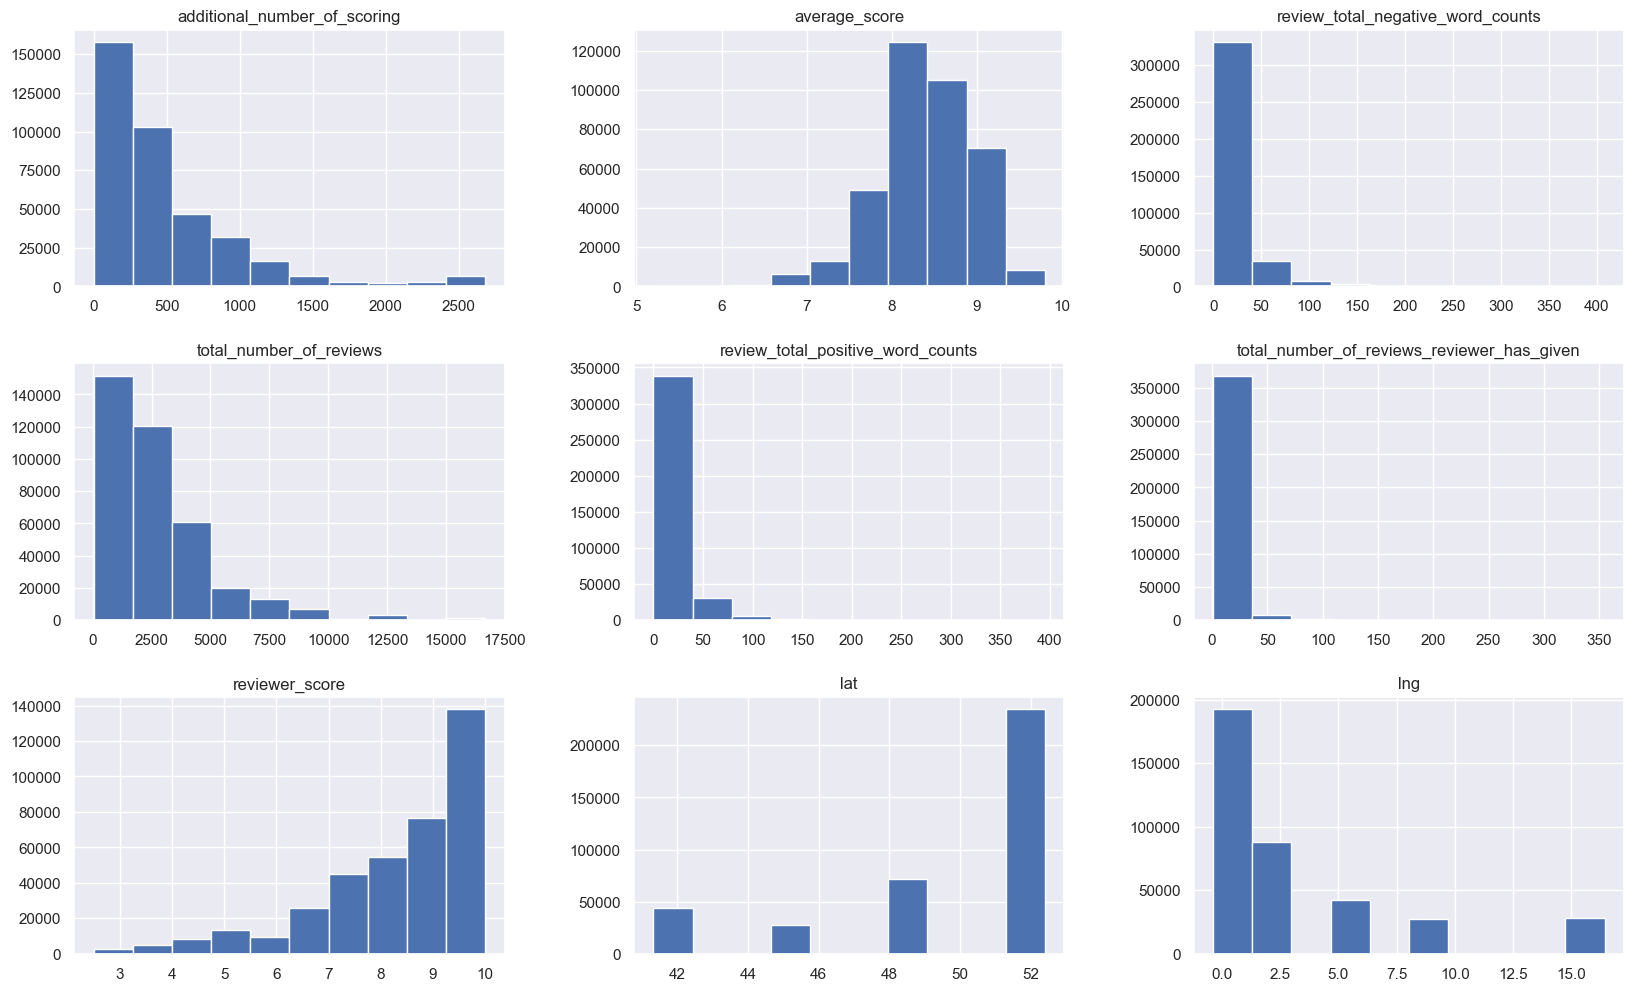

In [84]:
hotels[num_cols].hist(figsize=(20,12))
plt.show()

Проверим числовые признаки на нормальность 

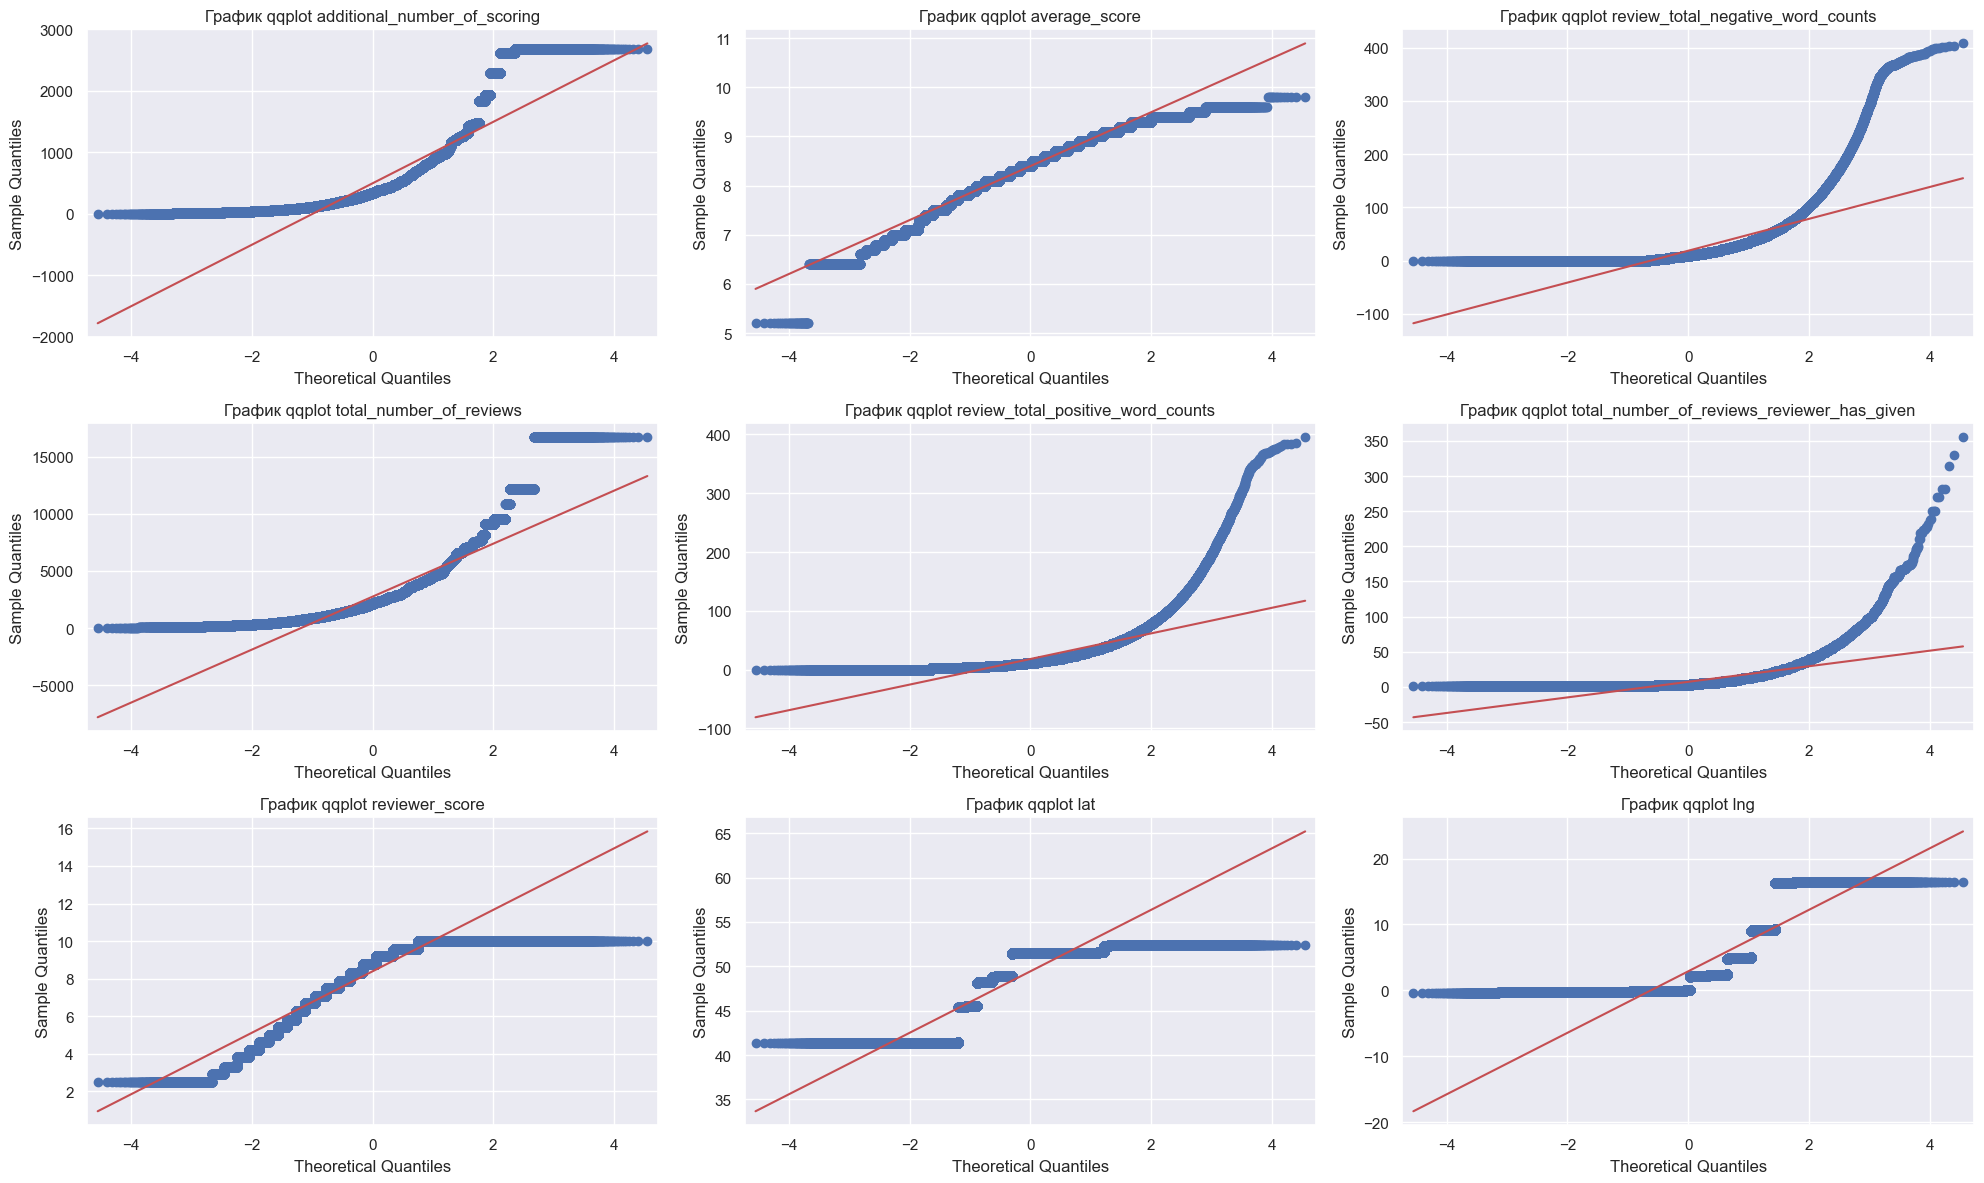

In [85]:
# Создаем графики qqplot (квантиль-квантиль график)
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.ravel()  # Преобразуем матрицу осей в плоский массив

for i, column in enumerate(num_cols):  # Ограничиваем 9 графиками для 3x3 сетки
    sm.qqplot(hotels[column].dropna(), line='s', ax=axes[i])
    axes[i].set_title(f"График qqplot {column}")
plt.tight_layout()
plt.show()
    

        Все признаки распределенны ненормально                           

Следовательно, при построении матрицы корреляций для числовых признаков будем использовать метод *spearman*

Рассмотрим основной числовой признак оценка рецензента - *reviewer_score*

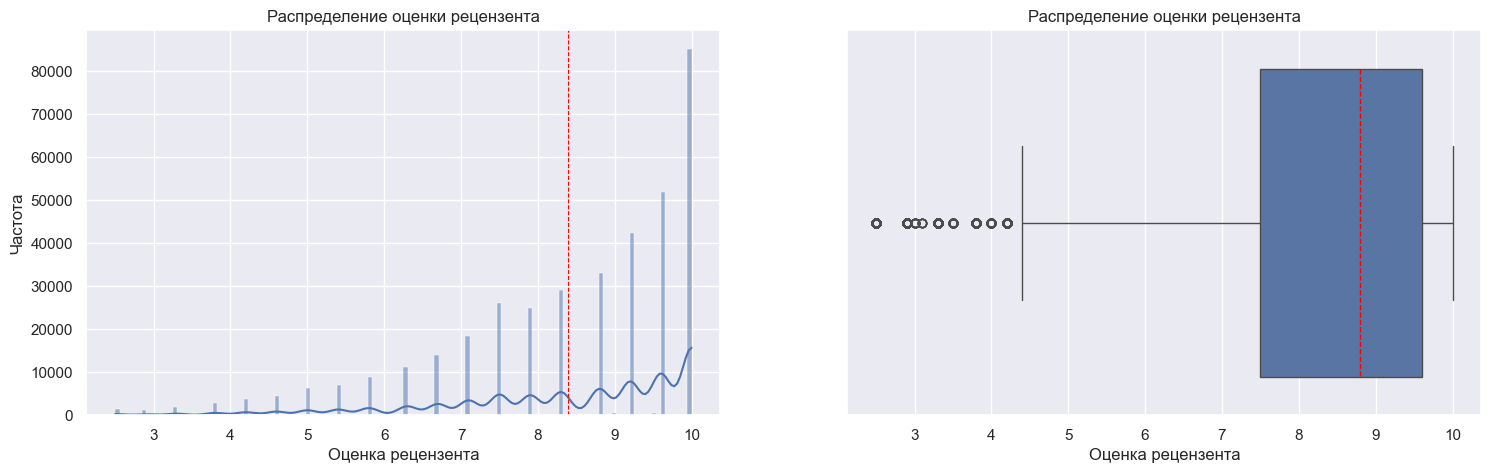

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(hotels['reviewer_score'], kde=True, ax=axes[0])
axes[0].set(xlabel='Оценка рецензента', ylabel='Частота')
axes[0].set_title('Распределение оценки рецензента')
axes[0].axvline(hotels['reviewer_score'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(hotels['reviewer_score'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Оценка рецензента')
axes[1].set_title('Распределение оценки рецензента')

plt.show()

In [87]:
hotels['reviewer_score'].describe().round(2).to_frame()

,reviewer_score
count,377993.00
mean,8.39
std,1.64
min,2.50
25%,7.50
50%,8.80
75%,9.60
max,10.00


**Выводы:**
-   Оценки смещены вправо (в сторону высоких значений) — большинство оценок сосредоточены в диапазоне 7–10.
-   Мало оценок ниже 5 баллов — гости редко ставят очень низкие оценки.
-   Распределение не является нормальным (нет симметрии вокруг среднего).
-   Гости чаще оставляют положительные оценки

Рассмотрим такие признаки как: 
-  *review_total_negative_word_counts* — количество слов в положительном отзыве (целое число).

-   *review_total_positive_word_counts* — количество слов в положительном отзыве (целое число).

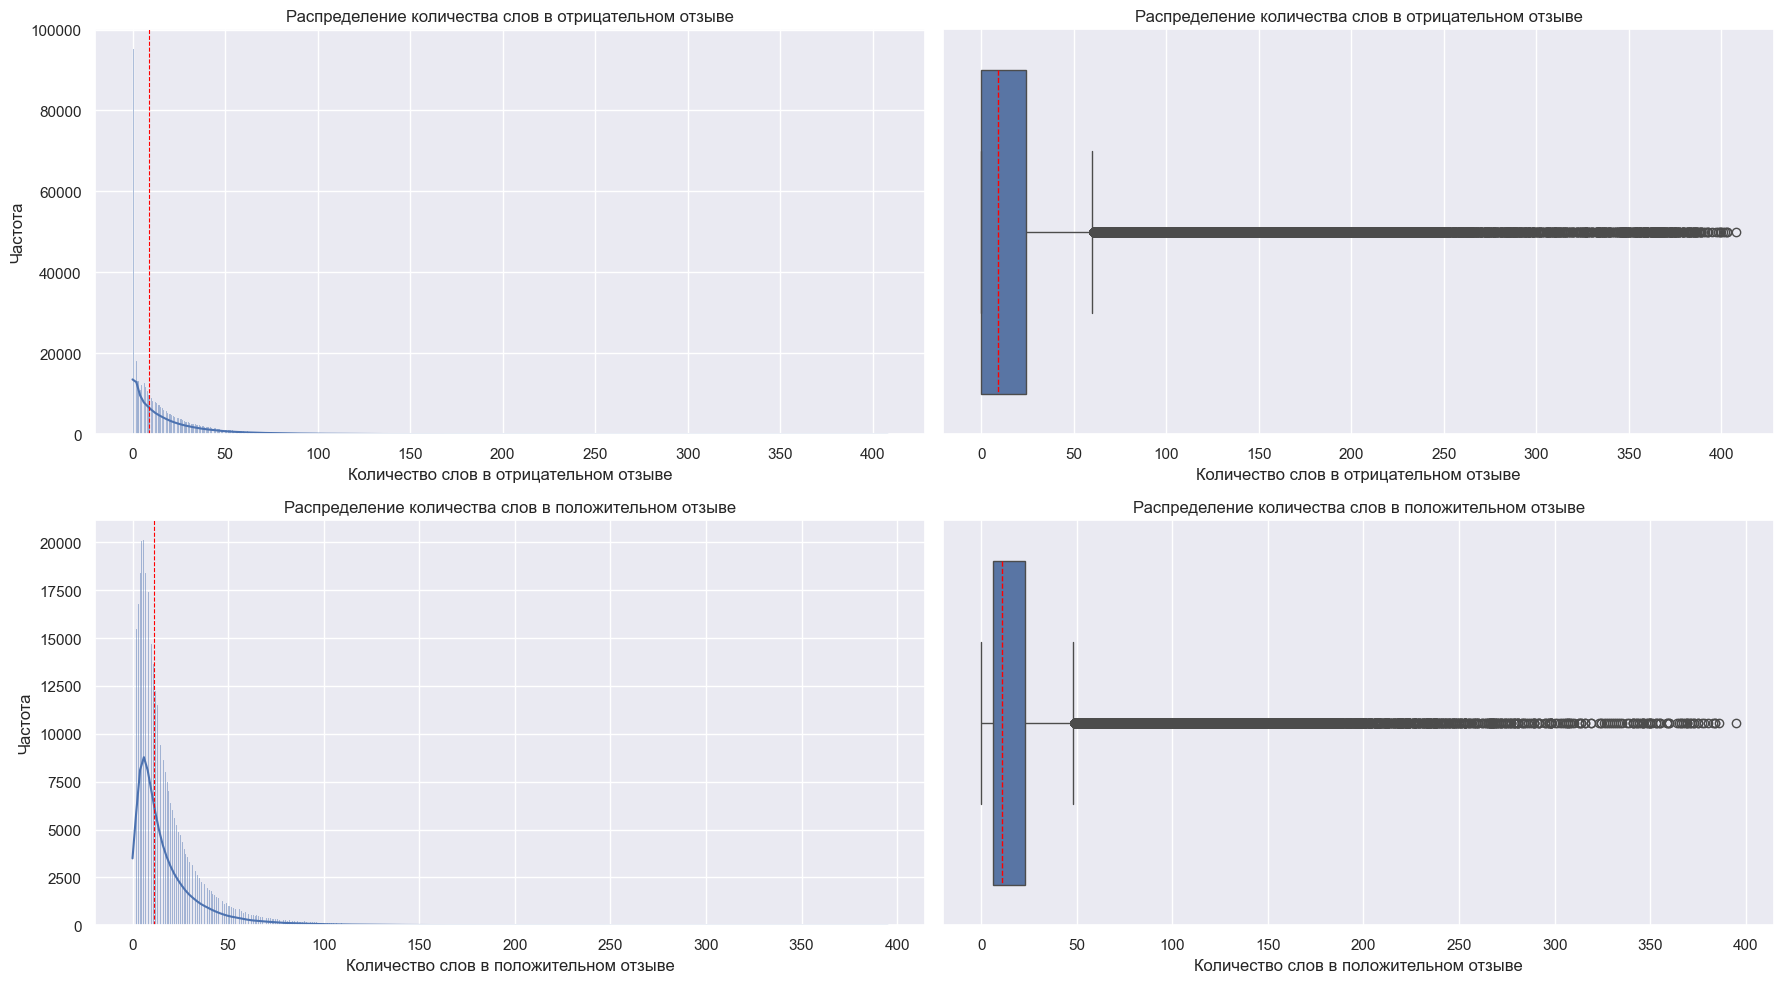

In [88]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()  # Преобразуем матрицу осей в плоский массив

sns.histplot(hotels['review_total_negative_word_counts'], kde=True, ax=axes[0])
axes[0].set(xlabel='Количество слов в отрицательном отзыве', ylabel='Частота')
axes[0].set_title('Распределение количества слов в отрицательном отзыве')
axes[0].axvline(hotels['review_total_negative_word_counts'].median(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(hotels['review_total_negative_word_counts'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Количество слов в отрицательном отзыве')
axes[1].set_title('Распределение количества слов в отрицательном отзыве')

sns.histplot(hotels['review_total_positive_word_counts'], kde=True, ax=axes[2])
axes[2].set(xlabel='Количество слов в положительном отзыве', ylabel='Частота')
axes[2].set_title('Распределение количества слов в положительном отзыве')
axes[2].axvline(hotels['review_total_positive_word_counts'].median(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(hotels['review_total_positive_word_counts'], ax=axes[3], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[3].set(xlabel='Количество слов в положительном отзыве')
axes[3].set_title('Распределение количества слов в положительном отзыве')

plt.tight_layout()
plt.show()

In [89]:
display(hotels['review_total_negative_word_counts'].describe())
display(hotels['review_total_positive_word_counts'].describe())

count    377993.000000
mean         18.621715
std          29.915589
min           0.000000
25%           0.000000
50%           9.000000
75%          24.000000
max         408.000000
Name: review_total_negative_word_counts, dtype: float64

count    377993.000000
mean         18.145114
std          21.759196
min           0.000000
25%           6.000000
50%          11.000000
75%          23.000000
max         395.000000
Name: review_total_positive_word_counts, dtype: float64

**Вводы:**
-   видны очивидные выбросы, стоить понять что с ними делать 
-   есть даннные где количество слов 0 (следует их изучить) 

Выбросов много, но они реальны, действительно могут быть оставленны такие отзывы (возможно следует изучить их боллее подробно)

### Для начала рассмотрим отзывы с нулевым количеством слов в отзывах

In [90]:
positive_zero = hotels['review_total_positive_word_counts'] == 0
negative_zero = hotels['review_total_negative_word_counts'] == 0

# либо в одном, либо во втором признаке не написан отзыв
review_total_zero = hotels[positive_zero | negative_zero].reset_index()

pivot = review_total_zero[['reviewer_score',
                           'review_total_positive_word_counts',
                           'review_total_negative_word_counts']].copy()


display(pivot.describe().round(2))

,reviewer_score,review_total_positive_word_counts,review_total_negative_word_counts
count,114185.0,114185.00,114185.00
mean,8.8,16.77,4.91
std,1.6,20.94,18.64
min,2.5,0.00,0.00
25%,8.3,4.00,0.00
50%,9.6,11.00,0.00
75%,10.0,22.00,0.00
max,10.0,384.00,402.00


In [91]:
# Средняя оценка у групп
print("Оценки у пользователей без текста хотя бы в одном отзыве:")
display(pivot['reviewer_score'].describe().round(2).to_frame())
print("\nОценки у всех пользователей:")
display(hotels['reviewer_score'].describe().round(2).to_frame())

Оценки у пользователей без текста хотя бы в одном отзыве:


,reviewer_score
count,114185.0
mean,8.8
std,1.6
min,2.5
25%,8.3
50%,9.6
75%,10.0
max,10.0



Оценки у всех пользователей:


,reviewer_score
count,377993.00
mean,8.39
std,1.64
min,2.50
25%,7.50
50%,8.80
75%,9.60
max,10.00


In [92]:
# Процент пользователей без слов хотя бы в одном отзыве
no_text_users = len(review_total_zero) / len(hotels) * 100
print(f"Доля пользователей без текста: {no_text_users:.1f}%")

Доля пользователей без текста: 30.2%


Text(0.5, 1.0, 'Корреляция признаков')

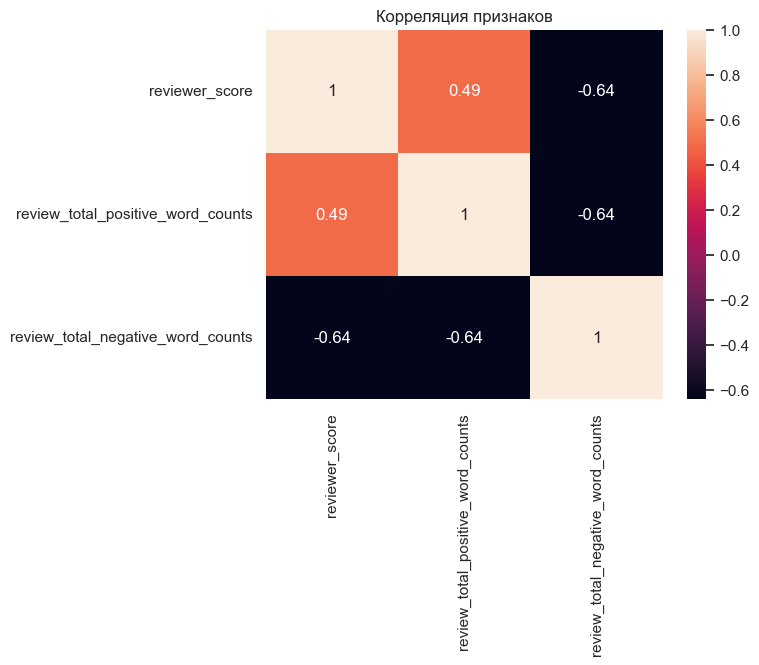

In [93]:
sns.heatmap(pivot.corr(method='spearman'), annot=True)
plt.title("Корреляция признаков")

**Выводы на выборке, где пользователь не оставил отзыв хотя бы в одном из призанков:**
-   Найденна сильная взаимосвязь между количествами положительных и отрицательных слов в отзыве. Это значит что, если пользователь оставил позитивный отзыв, то врядли он будет что-то писать в негративном пункте.
-   Также найдена умеренная взаимосвязь между review_total_negative_word_counts и reviewer_score , review_total_positive_word_counts и reviewer_score

### Предлагаю ввести признаки is_negative_zero, is_positive_zero

In [94]:
hotels['is_negative_zero'] = hotels['review_total_negative_word_counts'].apply(lambda x: 1 if x==0 else 0)
hotels['is_positive_zero'] = hotels['review_total_positive_word_counts'].apply(lambda x: 1 if x==0 else 0)

Часто в жизни случается, что ожидание не совпадает с реальность особенно в контексте выбора отеля. Давайте рассмотрим выбросы более подробно, чаще всего когда человек пишет много слов в отзыве значит ему  действительно есть, что написать - неважно плохой или хороший отзыв, у человека возникает много негативных эмоций, поэтому он отыгрывается на отзывах.

Так ли это в действительности, проверим это!

<Axes: >

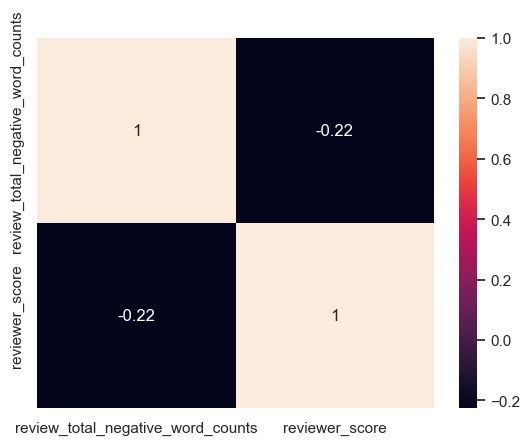

In [95]:
mask = hotels['review_total_negative_word_counts'] >= 50

negative_outlier = hotels[mask]
#negative_outlier.head(10)

sns.heatmap(negative_outlier[['review_total_negative_word_counts',
                              'reviewer_score']].corr(), annot=True)

сильной связи не наблюдается, разбивать на группы нет смысла 

> ### **На основе признаков *review_total_negative_word_counts* и *review_total_positive_word_counts* создадим более сильные признаки**

Cоздаем новый признак отношение количества негативных слов в отзыве на положительных

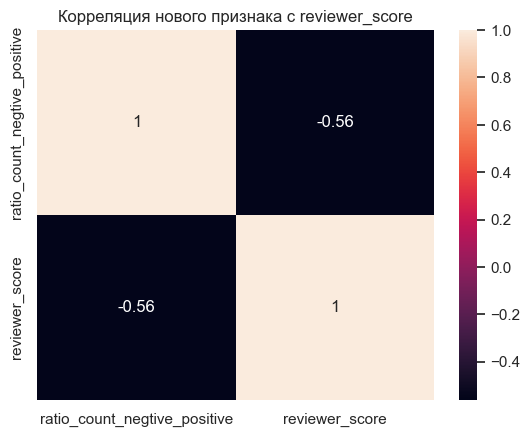

In [96]:
# принак просто их отношения (без обраюотки)
hotels['ratio_count_negtive_positive'] = hotels['review_total_negative_word_counts'] / hotels['review_total_positive_word_counts']
sns.heatmap(hotels[['ratio_count_negtive_positive', 'reviewer_score']].corr('spearman'), annot=True)
plt.title("Корреляция нового признака с reviewer_score")
plt.show()

Однако в варианте выше не обрабатываются неопределенности и исключения. Создадим обработанный признак из вышесозданного, а также отнесем каждый из вариантов к каждой категории. Также удалим его так как мы создадим признак без неопределенности. 

In [97]:
hotels.drop('ratio_count_negtive_positive', axis=1, inplace=True)

In [98]:
def calculate_enhanced_sentiment(row):
    neg = row['review_total_negative_word_counts']
    pos = row['review_total_positive_word_counts']
    
    # Случай 1: Оба не нули
    if neg > 0 and pos > 0:
        ratio = neg / pos
        return ratio, 'normal'
    
    # Случай 2: Только негативные слова
    elif neg > 0 and pos == 0:
        # Используем логарифмированное количество негативных слов
        log_neg = np.log1p(neg)  # log(neg + 1) для избежания нуля
        return log_neg, 'pure_negative'
    
    # Случай 3: Только позитивные слова
    elif pos > 0 and neg == 0:
        # Обратное логарифмированное количество позитивных слов
        log_pos = -np.log1p(pos)  # Отрицательное значение для позитива
        return log_pos, 'pure_positive'
    
    # Случай 4: Оба нули
    else:
        return 0, 'empty'

# Создаем два новых признака
hotels[['sentiment_metric', 'sentiment_type']] = hotels.apply(
    lambda x: pd.Series(calculate_enhanced_sentiment(x)), 
    axis=1
)

hotels['sentiment_type'] = hotels['sentiment_type'].astype('category')



In [99]:
hotels['sentiment_type'].value_counts()

sentiment_type
normal           263808
pure_positive     95259
pure_negative     18894
empty                32
Name: count, dtype: int64

In [100]:
# Используем One-Hot Encoding
sentiment_dummies = pd.get_dummies(hotels['sentiment_type'], prefix='sentiment')

# Добавляем новые колонки к исходному DataFrame
hotels = pd.concat([hotels, sentiment_dummies], axis=1)

# Удаляем исходный категориальный признак
hotels = hotels.drop('sentiment_type', axis=1)

**Разделение на типы сигналов:**

-   *normal* - обычное отношение негатив/позитив

-   *pure_negative* - только негативные слова

-   *pure_positive* - только позитивные слова

-   *empty* - оба нуля
**
Логарифмирование для чистых случаев:**

-   Для *pure_negative*: log(neg_words + 1) → чем больше негатива, тем выше значение

-   Для *pure_positive*: -log(pos_words + 1) → чем больше позитива, тем ниже значение

Попробуем сделать нменого другие признаки но несущую ту же логику

In [101]:
# Векторизованные вычисления
hotels['total_words'] = hotels['review_total_negative_word_counts'] + hotels['review_total_positive_word_counts']


hotels['log_sentiment_diff'] = (
    np.log1p(hotels['review_total_negative_word_counts']) 
    - np.log1p(hotels['review_total_positive_word_counts'])
)

mask_non_zero = hotels['total_words'] > 0
hotels['log_neg_normalized'] = 0
hotels.loc[mask_non_zero, 'log_neg_normalized'] = (
    np.log1p(hotels['review_total_negative_word_counts']) 
    / np.log1p(hotels['total_words'])
).astype(float)

hotels['is_pure_negative'] = (
    (hotels['review_total_negative_word_counts'] > 0) 
    & (hotels['review_total_positive_word_counts'] == 0)
).astype(int)

hotels['is_pure_positive'] = (
    (hotels['review_total_positive_word_counts'] > 0) 
    & (hotels['review_total_negative_word_counts'] == 0)
).astype(int)

In [102]:
hotels['log_neg_normalized'].describe()

count    377993.000000
mean          0.597662
std           0.375413
min           0.000000
25%           0.000000
50%           0.763802
75%           0.897735
max           1.000000
Name: log_neg_normalized, dtype: float64

**Создадим признак *new_score* - он отражает интенсивность негативных слов в отзыве с учетом рейтинга отеля.**

In [103]:
hotels['new_score'] = hotels['log_neg_normalized'] / hotels['average_score']

In [104]:
hotels[['hotel_name',
        'average_score',
        'reviewer_score', 
        'new_score']]

# удаляем название отеля 
hotels.drop('hotel_name', axis=1, inplace=True)

In [105]:
hotels[hotels['reviewer_score'] == 10].head()

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,lat,lng,review_year,...,sentiment_empty,sentiment_normal,sentiment_pure_negative,sentiment_pure_positive,total_words,log_sentiment_diff,log_neg_normalized,is_pure_negative,is_pure_positive,new_score
0,581,8.4,3,1994,4,7,10.0,51.507894,-0.143671,2016,...,False,True,False,False,7,-0.223144,0.666667,0,0,0.079365
3,34,7.5,0,607,11,8,10.0,48.888697,2.394540,2015,...,False,False,False,True,11,-2.484907,0.000000,0,1,0.000000
5,105,8.0,2,1607,16,1,10.0,45.448188,9.257046,2015,...,False,True,False,False,18,-1.734601,0.373114,0,0,0.046639
11,147,9.1,15,975,26,1,10.0,51.492029,-0.191780,2016,...,False,True,False,False,41,-0.523248,0.741796,0,0,0.081516
12,73,9.1,0,270,14,1,10.0,51.493091,-0.175502,2017,...,False,False,False,True,14,-2.708050,0.000000,0,1,0.000000


## **1.7 ГЕОГРАФИЧЕСКИЕ ПРИЗАНКИ**

# Проверить нет ли координат отеля в море 

Рассмотрим признаки географической долготы и ширины отеля:

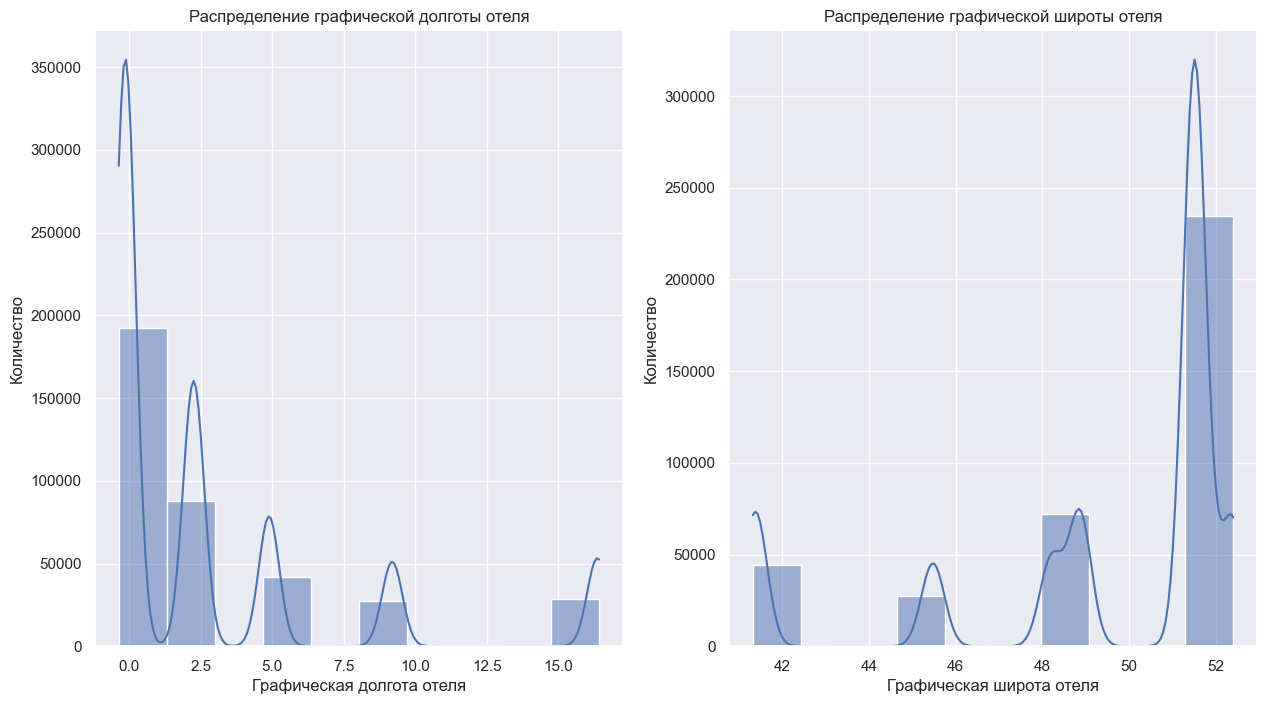

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
sns.histplot(hotels['lng'],
             kde=True,
             ax=axes[0],
             bins=10)
axes[0].set(xlabel="Графическая долгота отеля", ylabel="Количество")
axes[0].set_title('Распределение графической долготы отеля')


sns.histplot(hotels['lat'],
             kde=True,
             ax=axes[1],
             bins=10)
axes[1].set(xlabel="Графическая широта отеля", ylabel="Количество")
axes[1].set_title('Распределение графической широты отеля')

plt.show()

In [107]:
hotels.columns

Index(['additional_number_of_scoring', 'average_score',
       'review_total_negative_word_counts', 'total_number_of_reviews',
       'review_total_positive_word_counts',
       'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'lat',
       'lng', 'review_year', 'review_month', 'days_since_review_num',
       'hotel_city', 'is_patriot', 'economy_level_encoded', 'culture_pdi',
       'culture_idv', 'culture_mas', 'culture_uai', 'culture_lto',
       'culture_ind', 'is_capital', 'negative_review_neg',
       'negative_review_neu', 'negative_review_pos',
       'negative_review_compound', 'positive_review_neg',
       'positive_review_pos', 'positive_review_compound',
       'is_real_negative_review_category', 'negative_scale',
       'negative_scale_second', 'positive_scale', 'net_sentiment',
       'net_sentiment_normalized', 'weighted_sentiment',
       'mean_negative_review_scale', 'mean_positive_review_scale',
       'deviation_negative_review_scale', 'deviation_positi

Теперь узнаем координаты центра самого города, чтобы в дальнейшем узнать удаленность отеля от центра 

In [108]:
city_centre_coordinates = {
    "London": (51.5074, -0.1278),
    "Barcelona": (41.3851, 2.1734),
    "Paris": (48.8566, 2.3522),
    "Amsterdam": (52.3676, 4.9041),
    "Vienna": (48.2082, 16.3738),
    "Milan": (45.4642, 9.1900)
}


def calculate_distance_geopy(lat1, lon1, lat2, lon2):
    """
    Рассчитать расстояние с помощью geopy (более точно)
    Возвращает расстояние в километрах
    """
    point1 = (lat1, lon1)
    point2 = (lat2, lon2)
    return geodesic(point1, point2).kilometers




# Правильное применение apply
hotels['distance_to_centre_km'] = hotels.apply(
    lambda row: calculate_distance_geopy(
        row['lat'], 
        row['lng'],
        city_centre_coordinates[row['hotel_city']][0],  # центр lat
        city_centre_coordinates[row['hotel_city']][1]   # центр lng
    ),
    axis=1
)

hotels['distance_to_centre_km'].head() 


0    1.103257
1    1.548861
2    2.314372
3    4.731591
4    4.370494
Name: distance_to_centre_km, dtype: float64

In [109]:
# удаляем категориальный признак (мы его закодировали ранее)
hotels.drop('hotel_city', axis=1, inplace=True)

## 2. **Анализ и отбор признаков (Feature Selection)**

### 2.1 АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ

In [ ]:
def show_corr_heatmap(columns_list, title, method):
    """Построения корреляционной диаграммы"""
    fig, ax_ = plt.subplots(figsize=(15, 12))
    corr = hotels[columns_list].corr(method=method)

    sns.heatmap(corr, 
                annot=True, 
                linewidths=0.1, 
                ax=ax_, 
                cmap='viridis',
                fmt='.2g')
    ax_.set_title(title, fontsize=18)
    plt.show()


In [ ]:
show_corr_heatmap(hotels.select_dtypes('number').columns,
                  'Корреляционная карта',
                  'spearman')

**Ранжированная корреляция с целевой переменной**

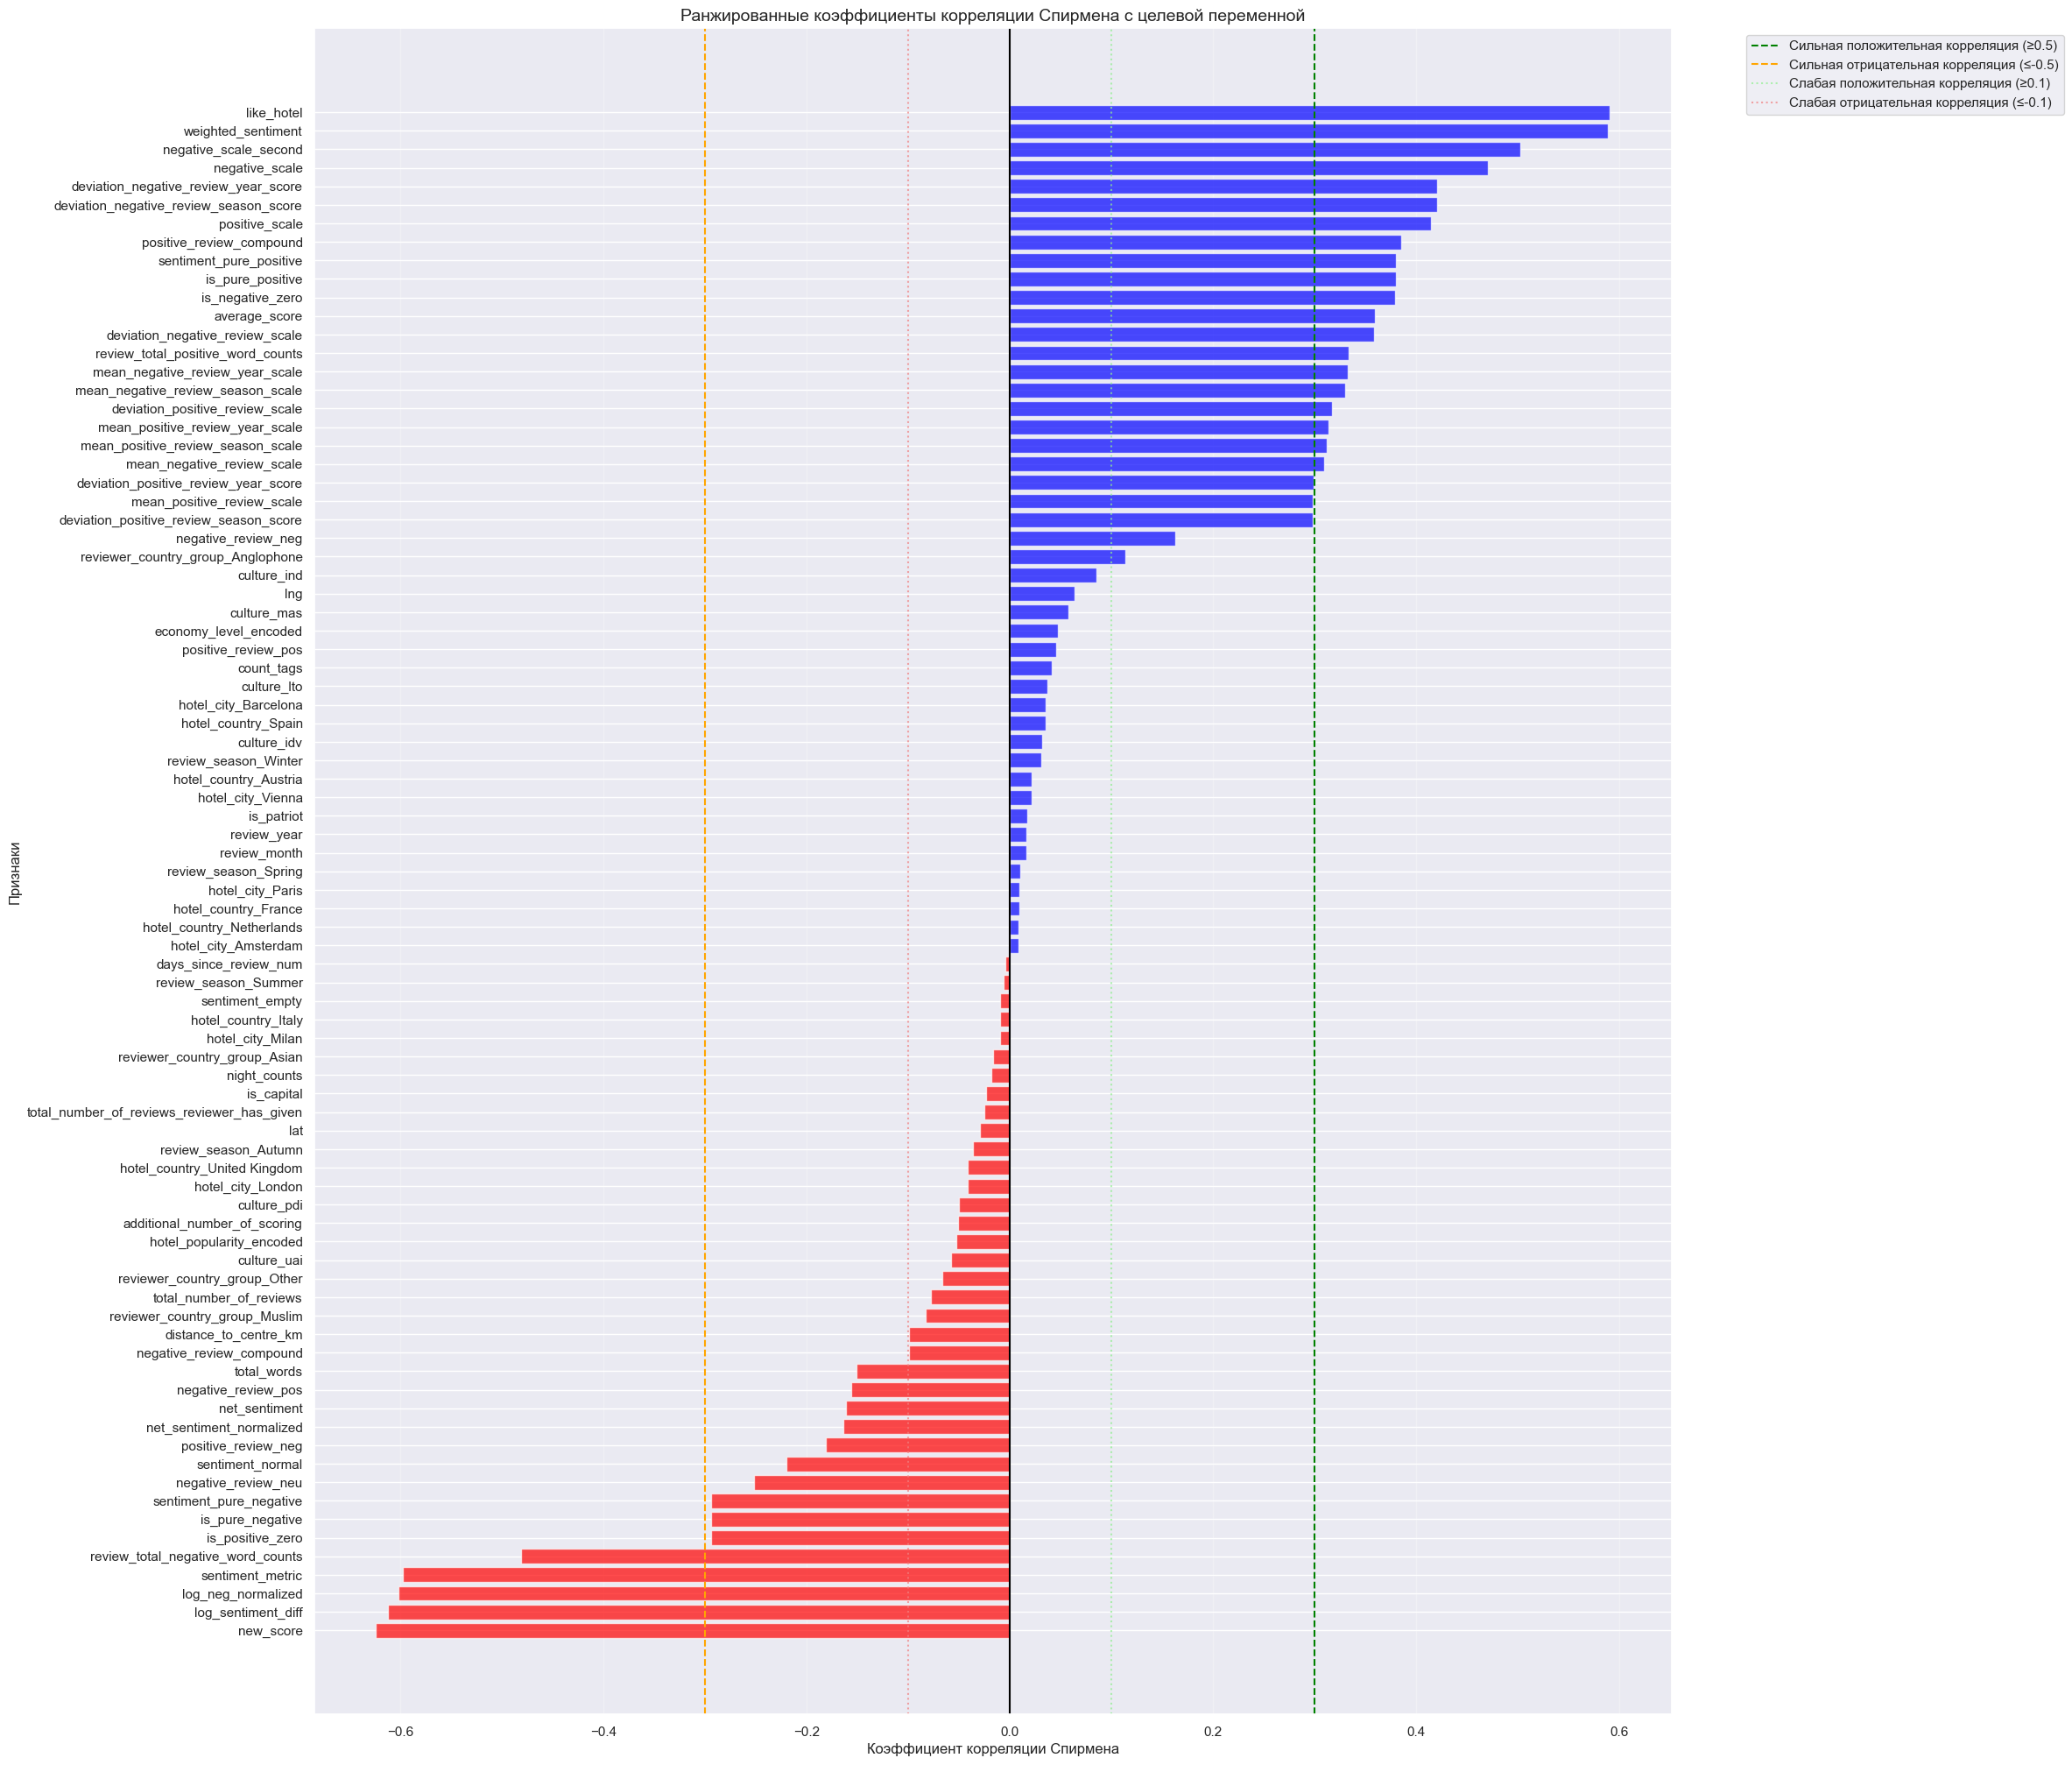

In [111]:
num_cols = [col for col in hotels.columns if hotels[col].dtypes not in ('object', 'category')]

# Вычисляем корреляционную матрицу методом Спирмена
correlation_matrix = hotels[num_cols].corr(method='spearman')

# Корреляции с целевой переменной 
target_correlations = correlation_matrix['reviewer_score'].sort_values(ascending=False)

plt.figure(figsize=(20, 25))

# Убираем саму целевую переменную из списка
target_corr_sorted = target_correlations.drop('reviewer_score').sort_values(ascending=True)

# Создаем цвета для положительных и отрицательных корреляций
colors = ['red' if x < 0 else 'blue' for x in target_corr_sorted.values]

# Строим горизонтальную барчарт
plt.barh(target_corr_sorted.index, target_corr_sorted.values, color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', alpha=1)

# Добавляем линии для средней корреляции (можно настроить пороги)
plt.axvline(x=0.3, color='green', linestyle='--', alpha=1, label='Сильная положительная корреляция (≥0.5)')
plt.axvline(x=-0.3, color='orange', linestyle='--', alpha=1, label='Сильная отрицательная корреляция (≤-0.5)')
plt.axvline(x=0.1, color='lightgreen', linestyle=':', alpha=0.7, label='Слабая положительная корреляция (≥0.1)')
plt.axvline(x=-0.1, color='lightcoral', linestyle=':', alpha=0.7, label='Слабая отрицательная корреляция (≤-0.1)')

plt.xlabel('Коэффициент корреляции Спирмена', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.title('Ранжированные коэффициенты корреляции Спирмена с целевой переменной', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)

### 2.2 ОТБОР ВЛИЯТЕЛЬНЫХ ПРИЗНАКОВ

> Рассмотрим группу признаков, состоящую из:
-   *is_real_negative_review_category*
-   *negative_scale*
-   *negative_scale_second*

Все эти признаки приближенные друг к другу и между ними наблюдается мультиколлинеарность. Отберем лучший признак из них с помощью SelectKbest.


In [112]:
cols = [
    'is_real_negative_review_category', 
    'negative_scale',
    'negative_scale_second',
]

X = hotels[cols]
y = hotels['reviewer_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.25,
    random_state=42)

selector = SelectKBest(f_regression, k=1)
selector.fit(X_train, y_train)
 
print("Выбранный признак:", selector.get_feature_names_out())

# Посмотрите F-values (статистики) для всех признаков
print("\nF-values для каждого признака:")
for i, col in enumerate(cols):
    print(f"{col}: {selector.scores_[i]:.4f}")

# И p-values
print("\nP-values для каждого признака:")
for i, col in enumerate(cols):
    print(f"{col}: {selector.pvalues_[i]:.2f}")


Выбранный признак: ['negative_scale_second']

F-values для каждого признака:
is_real_negative_review_category: 66173.6836
negative_scale: 73644.6788
negative_scale_second: 86701.7016

P-values для каждого признака:
is_real_negative_review_category: 0.00
negative_scale: 0.00
negative_scale_second: 0.00


In [113]:
hotels.drop(['is_real_negative_review_category', 'negative_scale'],
            axis=1, inplace=True)

> *Произведем отбор лучших признаков на основе метода рекрсивного отбора признаков - RFE*

Будем использовать модель линейной регрессии, так как у нас достаточно мултиколлинеарных признаков. Отберем 30 самых влиятельных признаков.

In [139]:
X = hotels.drop('reviewer_score', axis=1)
y = hotels['reviewer_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.25,
    random_state=42)

estimator = LinearRegression()

selector = RFE(estimator, n_features_to_select=30, step=1)
selector = selector.fit(X_train, y_train)
 
finall_cols = selector.get_feature_names_out()
print(finall_cols, end='\n')

print(selector.ranking_)


['average_score' 'negative_review_neu' 'negative_review_pos'
 'negative_review_compound' 'positive_review_neg' 'positive_review_pos'
 'positive_review_compound' 'negative_scale_second' 'positive_scale'
 'net_sentiment_normalized' 'weighted_sentiment'
 'deviation_positive_review_scale' 'mean_positive_review_year_scale'
 'deviation_positive_review_year_score'
 'mean_positive_review_season_scale'
 'deviation_positive_review_season_score' 'like_hotel'
 'reviewer_country_group_Anglophone' 'reviewer_country_group_Muslim'
 'is_negative_zero' 'is_positive_zero' 'sentiment_empty'
 'sentiment_normal' 'sentiment_pure_negative' 'sentiment_pure_positive'
 'log_sentiment_diff' 'log_neg_normalized' 'is_pure_negative'
 'is_pure_positive' 'new_score']
[51  1 35 52 41 47 15 22 33 34 50 20 29 43 44 46 42 49 48  9 28  1  1  1
  1  1  1  1  1  1  1  2 36  3  1  4  1  5  1 17  1 16  1  1 45 32 23  1
  6  1 31 14 13 26 19  8 38  7 10 37 25 11 12 24 21 30 18  1  1 27  1  1
  1  1 40  1  1  1  1  1 39]


##  3.**Обучение модели и подбор параметров (Model Training)** 

In [ ]:
X = hotels[finall_cols]
y = hotels['reviewer_score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.25,
    random_state=42)

# стандартизируем признаки 
scaler = preprocessing.StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100,
                            #  verbose=2,
                             n_jobs=-1)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train_scaled, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой и тренировочной выборке.
y_train_pred = regr.predict(X_train_scaled)
y_test_pred = regr.predict(X_test_scaled)  

In [ ]:
print(f"MAPE значение для train выборки: {metrics.mean_absolute_percentage_error(y_train, y_train_pred)}")
print(f"MAPE значение для test выборки: {metrics.mean_absolute_percentage_error(y_test, y_test_pred)}")

MAPE значение для train выборки: 0.04396359176815051
MAPE значение для test выборки: 0.11877603267926962


Можем заметить явное переобучение, попробуем подобрать оптимальные параметры с помощью Optuna.

> ### **Подбор гиперпараметров модели** 

In [ ]:
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
  max_depth = trial.suggest_int('max_depth', 15, 40, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 10, 1)

  # создаем модель
  model = RandomForestRegressor(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          n_jobs=-1,
                                          random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  score = metrics.mean_absolute_percentage_error(y_train, model.predict(X_train_scaled))

  return score

In [ ]:
# %%time
# # cоздаем объект исследования
# study = optuna.create_study(study_name="RandomForestRegressor", direction="minimize")
# # ищем лучшую комбинацию гиперпараметров n_trials раз
# study.optimize(optuna_rf, n_trials=20)

[I 2025-09-25 14:30:14,063] A new study created in memory with name: RandomForestRegressor
[I 2025-09-25 14:31:03,811] Trial 0 finished with value: 0.09174467681255873 and parameters: {'n_estimators': 120, 'max_depth': 25, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.09174467681255873.
[I 2025-09-25 14:32:13,037] Trial 1 finished with value: 0.08669044321985443 and parameters: {'n_estimators': 160, 'max_depth': 22, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.08669044321985443.
[I 2025-09-25 14:32:50,432] Trial 2 finished with value: 0.09841199000452108 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.08669044321985443.
[I 2025-09-25 14:34:32,856] Trial 3 finished with value: 0.061494266830951876 and parameters: {'n_estimators': 210, 'max_depth': 37, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.061494266830951876.
[I 2025-09-25 14:36:00,902] Trial 4 finished with value: 0.08415493451632117 and param

CPU times: total: 7h 53min 36s
Wall time: 33min 59s


In [ ]:
# # выводим результаты на обучающей выборке
# print("Наилучшие значения гиперпараметров {}".format(study.best_params))
# print("MAPE на обучающем наборе: {:.3f}".format(study.best_value))

Наилучшие значения гиперпараметров {'n_estimators': 210, 'max_depth': 37, 'min_samples_leaf': 3}
MAPE на обучающем наборе: 0.061


In [ ]:
best_params = {'n_estimators': 210, 'max_depth': 37, 'min_samples_leaf': 3}

In [ ]:
# рассчитаем точность для тестовой выборки
model = RandomForestRegressor(best_params, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print('MAPE на тренировочном наборе: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_train, y_train_pred)))
print('MAPE на тестовом наборе: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_test, y_test_pred)))

MAPE на тренировочном наборе: 0.061
MAPE на тестовом наборе: 0.118


Не удалось улучшить метрику. Итоговый результат MAPE: 0.118

Рассмотрим подробнее процесс подбора гипперпараметров 

In [165]:
optuna.visualization.is_available()

True

In [167]:
optuna.visualization.plot_optimization_history(study, target_name="MAPE")

In [168]:
optuna.visualization.plot_param_importances(study, target_name="MAPE")

In [169]:
optuna.visualization.plot_contour(study, params=["max_depth", "n_estimators"],
                                  target_name="MAPE")

## 4.**Интерпретация результатов**

In [163]:
feature_importances = model.feature_importances_
feature_importances

array([2.42258800e-02, 2.40982054e-02, 1.24407474e-02, 1.01780661e-02,
       5.69171708e-03, 2.77196544e-02, 1.20857688e-02, 9.41180394e-03,
       2.08334162e-02, 1.59659966e-02, 1.68257888e-01, 3.22499511e-02,
       3.29046767e-02, 2.96024456e-02, 3.40873378e-02, 3.06835891e-02,
       1.77807508e-03, 6.86141314e-03, 3.21827023e-03, 1.43589578e-05,
       6.59905084e-05, 6.63862896e-08, 2.42229589e-04, 4.67844388e-05,
       1.50088638e-05, 3.18153525e-02, 3.09792728e-02, 6.16438207e-05,
       1.84469046e-05, 4.34445943e-01])

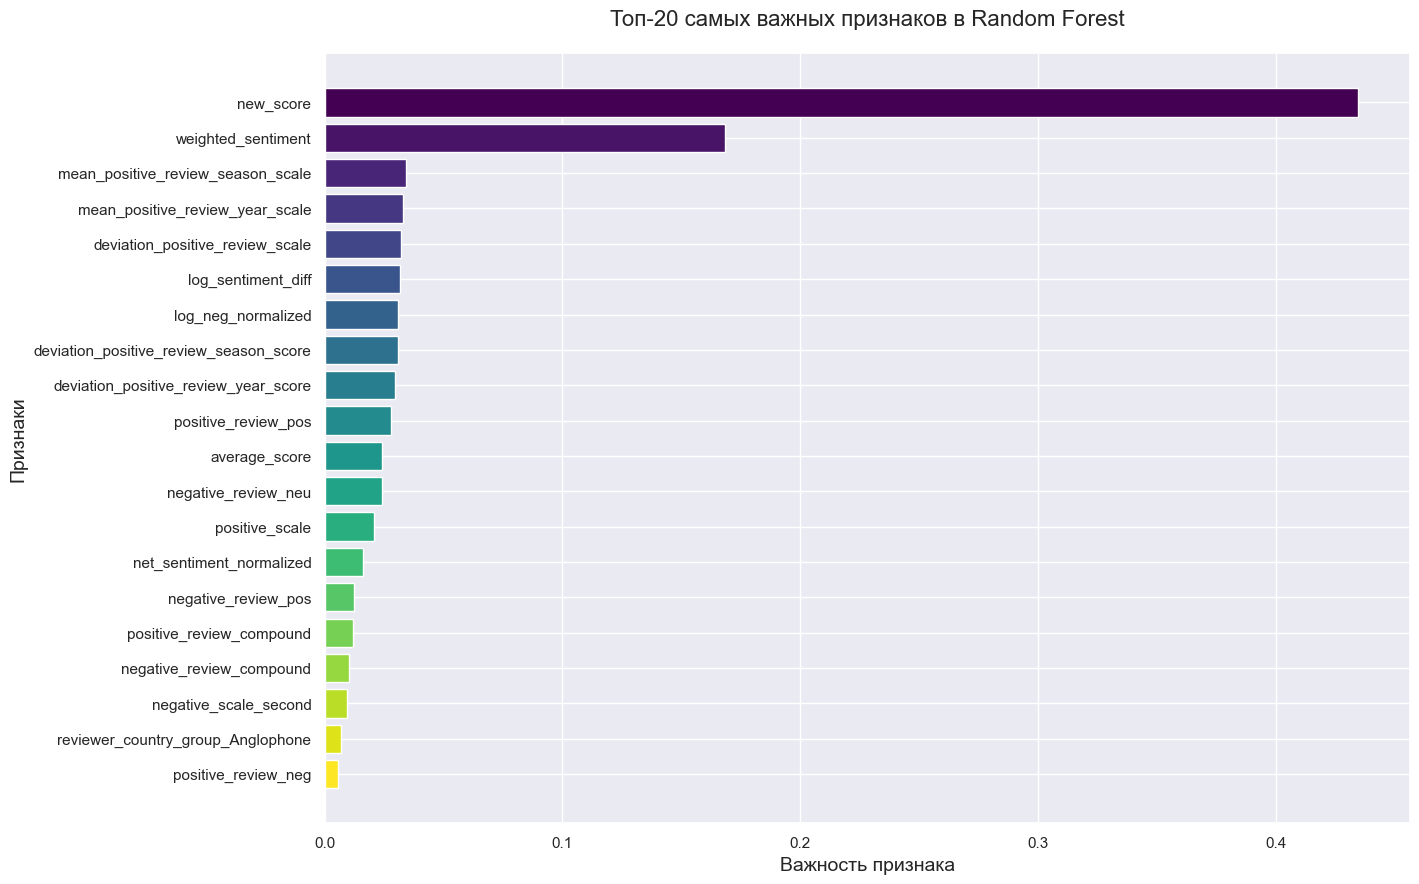

In [164]:
# Создаем DataFrame с важностью признаков
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

# Сортируем по убыванию важности
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Берем топ-20 самых важных признаков
top_features = feature_importance_df.head(20)

# Создаем визуализацию
plt.figure(figsize=(14, 10))
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

bars = plt.barh(top_features['feature'], top_features['importance'], color=colors)
plt.xlabel('Важность признака', fontsize=14)
plt.ylabel('Признаки', fontsize=14)
plt.title('Топ-20 самых важных признаков в Random Forest', fontsize=16, pad=20)
plt.gca().invert_yaxis()  # Самый важный признак сверху

> **Заключение:**

Целью исследования было создание модели машинного обучения для предсказания оценки (reviewer_score), которую рецензент ставит отелю на основе предоставленных данных. Задача является регрессионной, так как целевая переменная (reviewer_score) представляет собой непрерывное числовое значение.

Для решения задачи была выбрана модель RandomForestRegressor из библиотеки scikit-learn, которая хорошо подходит для задач регрессии благодаря своей способности обрабатывать нелинейные зависимости и устойчивости к переобучению. Для оптимизации гиперпараметров модели использовалась библиотека Optuna.

В результате оптимизации гиперпараметров с помощью Optuna была получена модель с итоговым значением метрики MAPE = 0.118 (11.8%) на тестовой выборке. Это указывает на то, что средняя абсолютная процентная ошибка предсказания оценок рецензентов составляет 11.8%, что является хорошим показателем для задач регрессии.